# MNIST-Fashion

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import itertools
import time
import os

# ==========================================
# 1. Real World Data Loading (Fashion MNIST)
# ==========================================

print("Fetching Fashion-MNIST from OpenML (this may take a moment)...")
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False, cache=True)
y = y.astype(int)
    

Fetching Fashion-MNIST from OpenML (this may take a moment)...


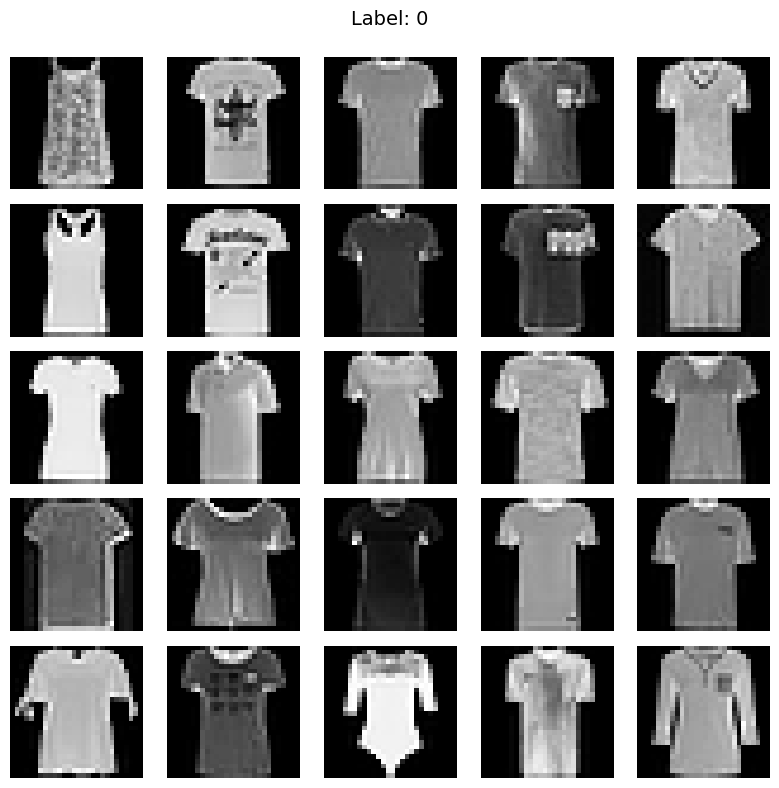

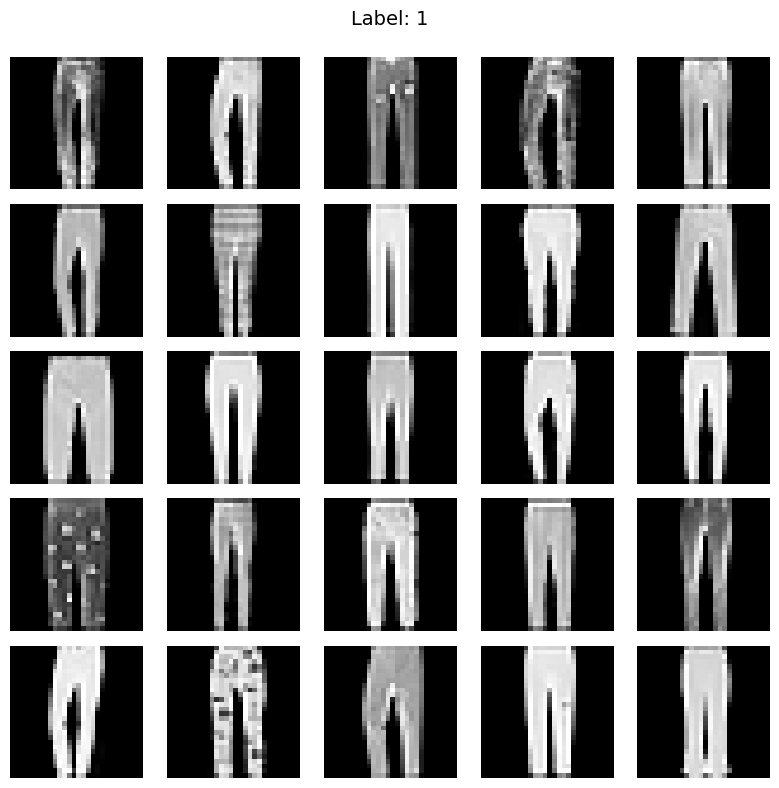

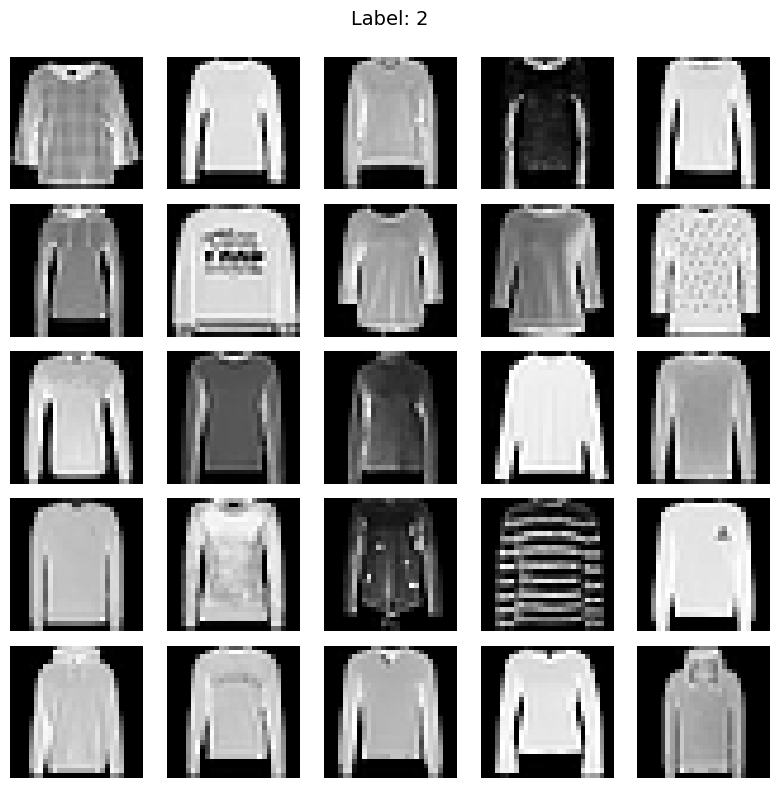

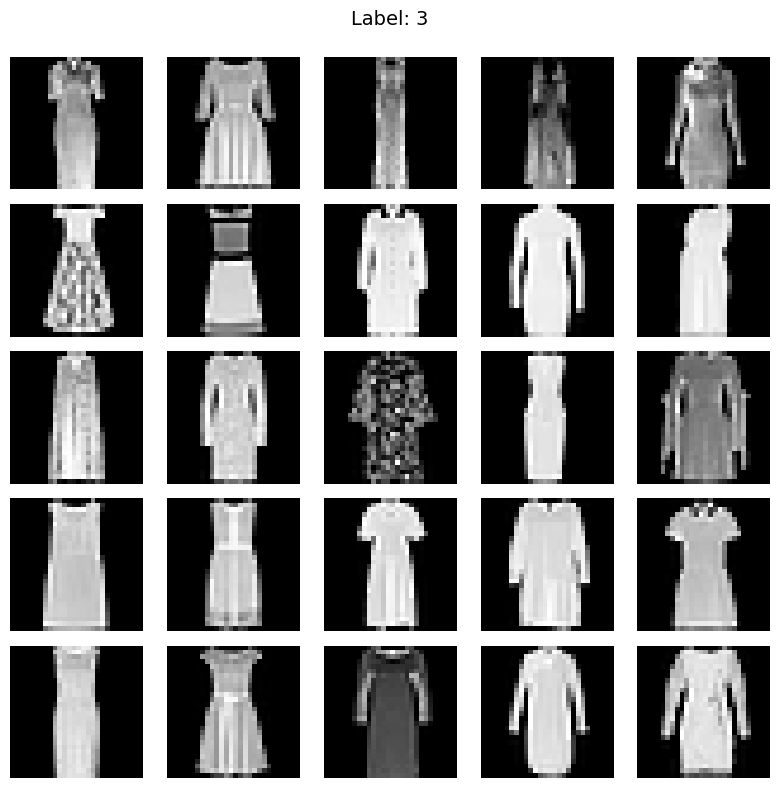

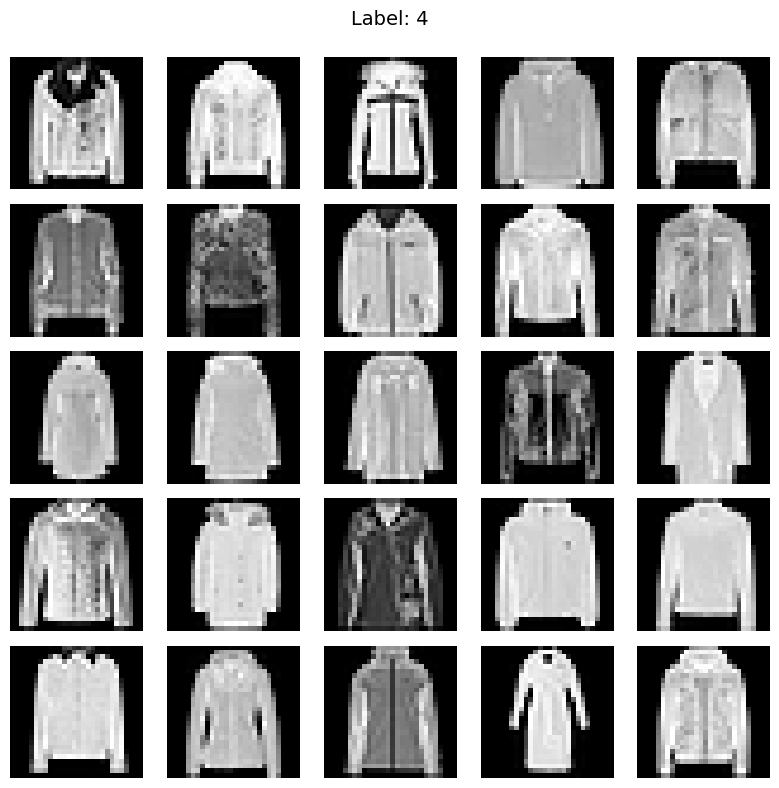

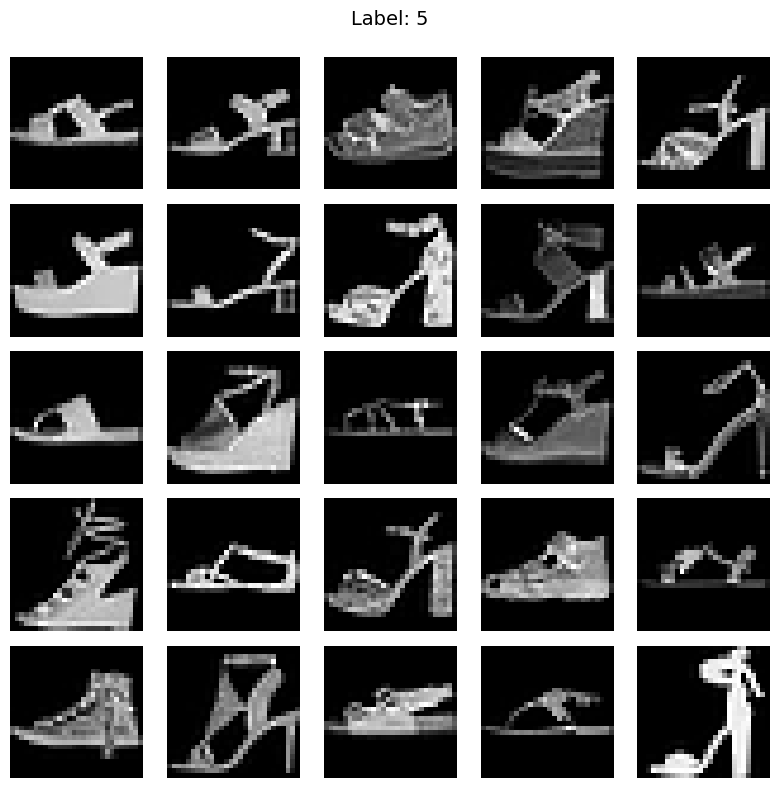

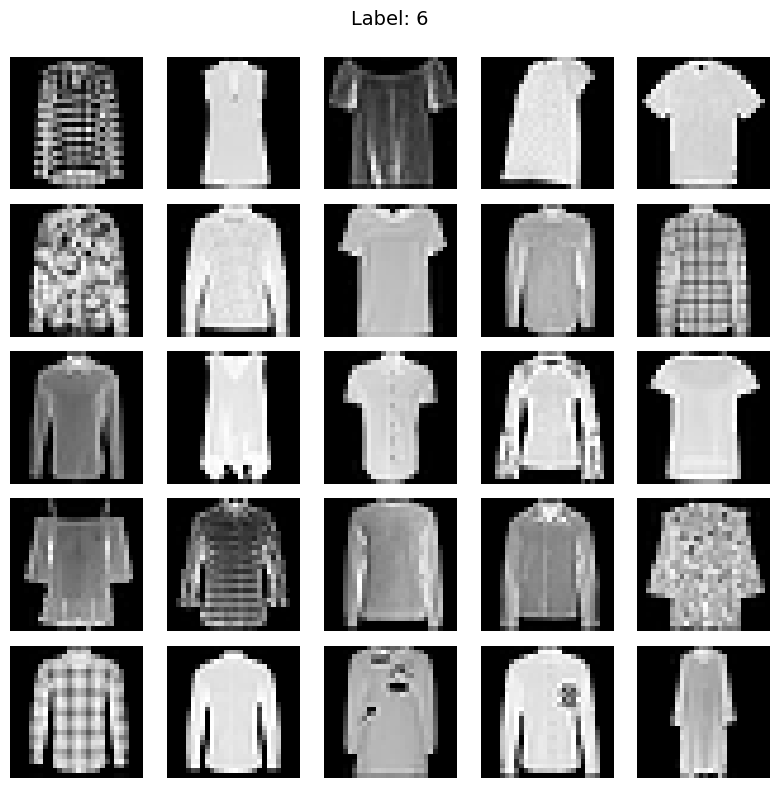

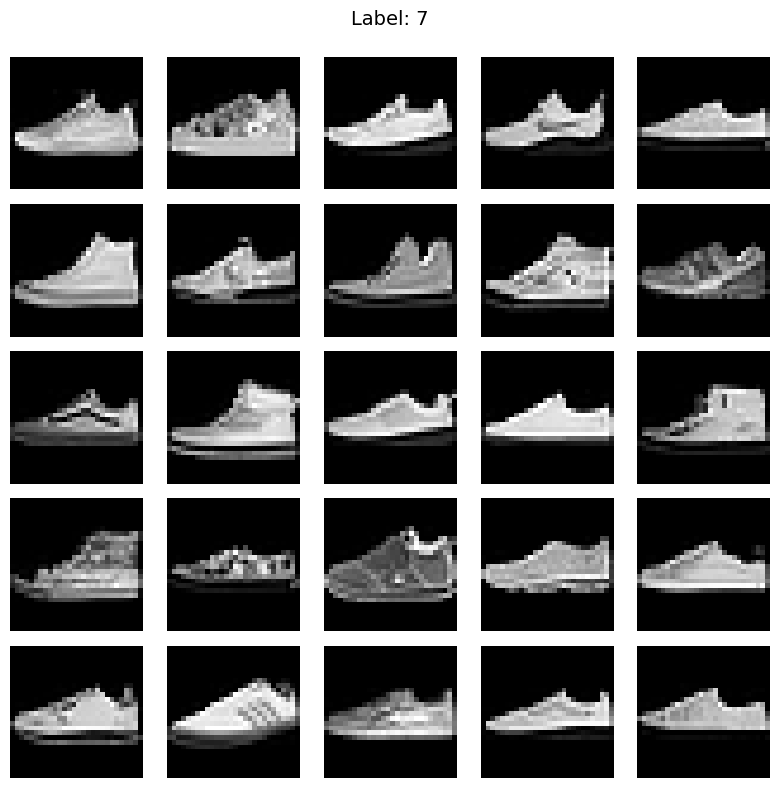

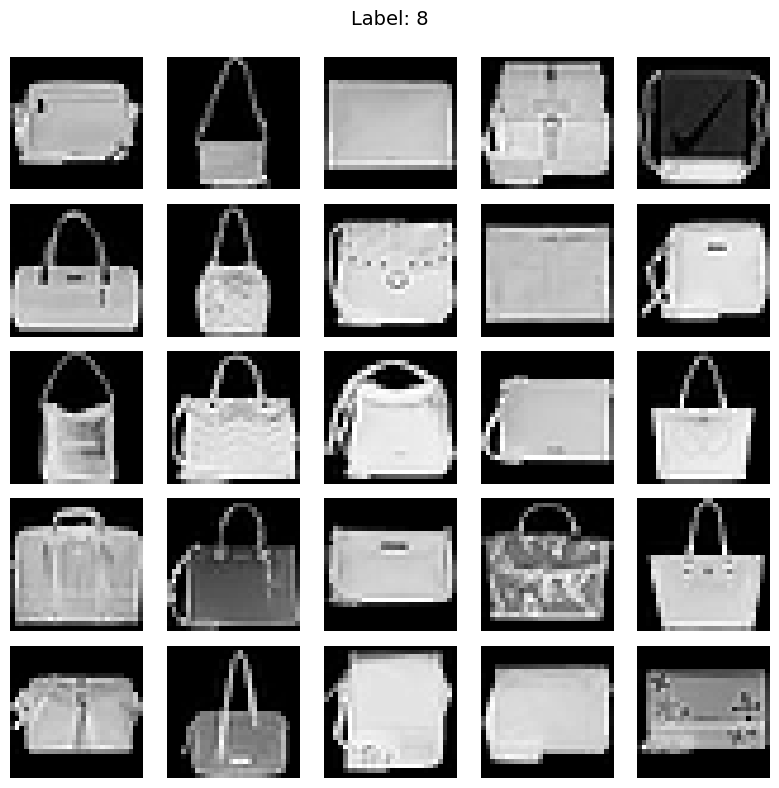

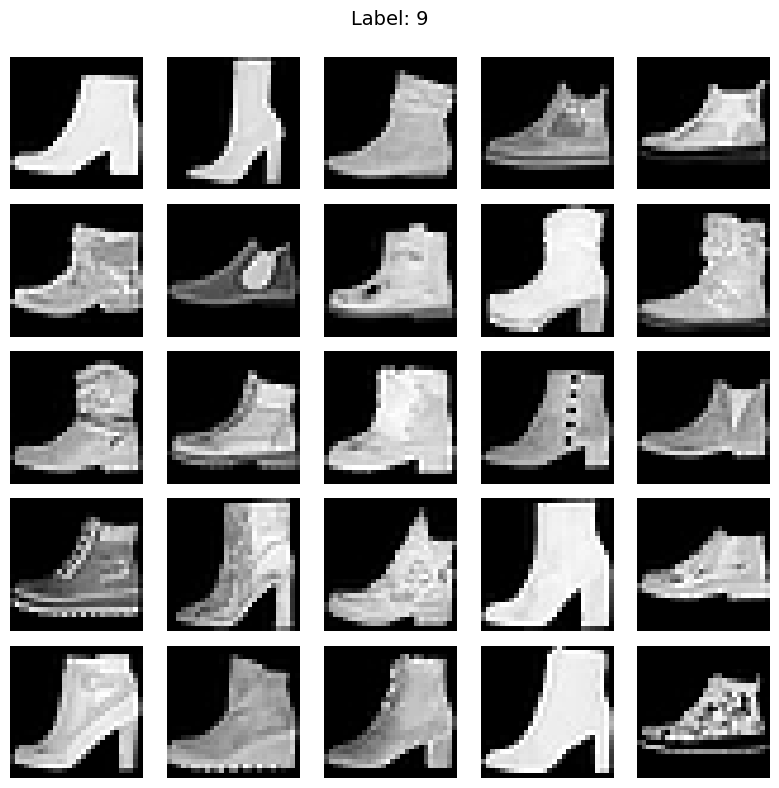

In [9]:
# Visualize 25 random images for each label
unique_labels = np.unique(y)

for label in unique_labels:
    # Get indices for this label
    label_indices = np.where(y == label)[0]
    
    # Select 25 random indices
    if len(label_indices) >= 25:
        indices = np.random.choice(label_indices, 25, replace=False)
    else:
        indices = label_indices
        
    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    fig.suptitle(f"Label: {label}", fontsize=14)
    
    for i, ax in enumerate(axes.flat):
        if i < len(indices):
            idx = indices[i]
            ax.imshow(X[idx].reshape(28, 28), cmap='gray')
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

In [ ]:
# PCA Projection of the entire dataset
print("Running PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.5, s=1)
plt.colorbar(scatter, label='Digit Label')
plt.title('PCA Projection of Fashion-MNIST')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Soybean

In [45]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# 1. Load Data
print("Loading Soybean data...")
soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
X_df = soybean.data
y_fine_raw = soybean.target

# 2. Impute Missing Values (Still as Strings)
# 'most_frequent' fills '?' with the mode category
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X_df)

# 3. CRITICAL STEP: Encode Features to Numbers
# Converts strings like 'normal' -> 0, 'abnormal' -> 1
encoder = OrdinalEncoder()
X = encoder.fit_transform(X_imputed)

# 4. Map Hierarchy (Fine -> Coarse)
hierarchy_map = {
    # --- Parent: Leaf Spots ---
    'brown-spot': 'Leaf Spots',
    'alternaria-leaf-spot': 'Leaf Spots',
    'frog-eye-leaf-spot': 'Leaf Spots',
    'phyllosticta-leaf-spot': 'Leaf Spots',
    'downy-mildew': 'Leaf Spots',
    'powdery-mildew': 'Leaf Spots',
    
    # --- Parent: Root/Stem Rots ---
    'diaporthe-stem-canker': 'Root/Stem Rots',
    'charcoal-rot': 'Root/Stem Rots',
    'rhizoctonia-root-rot': 'Root/Stem Rots',
    'phytophthora-rot': 'Root/Stem Rots',
    'brown-stem-rot': 'Root/Stem Rots',
    'anthracnose': 'Root/Stem Rots',
    'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
    
    # --- Parent: Bacterial ---
    'bacterial-blight': 'Bacterial',
    'bacterial-pustule': 'Bacterial',
    'purple-seed-stain': 'Bacterial',
    
    # --- Parent: Environmental/Other ---
    '2-4-d-injury': 'Environmental',
    'herbicide-injury': 'Environmental',
    'cyst-nematode': 'Environmental'
}

# Convert labels
y_fine_strings = y_fine_raw.astype(str)
y_coarse_strings = np.array([hierarchy_map.get(label, 'Other') for label in y_fine_strings])

# Encode Labels to Integers
le_fine = LabelEncoder()
y_fine = le_fine.fit_transform(y_fine_strings)

le_coarse = LabelEncoder()
y_coarse = le_coarse.fit_transform(y_coarse_strings)

print("--- Data Ready ---")
print(f"Features (X): {X.shape} (Type: {X.dtype})")
print(f"Coarse Labels: {le_coarse.classes_}")

# 5. Variance Check
def check_variance(X, y_c, y_f, parent_idx):
    # Calculate Variance of the Parent Group
    parent_mask = (y_c == parent_idx)
    if np.sum(parent_mask) == 0: return 0, 0 # Safety check
    parent_var = np.var(X[parent_mask], axis=0).mean()
    
    # Calculate Variance of ONE Child Subclass
    child_labels = np.unique(y_f[parent_mask])
    child_mask = (y_f == child_labels[0]) # Pick the first subclass found
    child_var = np.var(X[child_mask], axis=0).mean()
    
    return parent_var, child_var

# Test on Index 0 (usually 'Bacterial' or 'Environmental')
for parent_idx in range(len(le_coarse.classes_)):
    p_var, c_var = check_variance(X, y_coarse, y_fine, parent_idx=parent_idx)

    print(f"\nVariance Check for Parent Class '{le_coarse.classes_[parent_idx]}':")
    print(f"Parent Variance: {p_var:.4f}")
    print(f"Child Variance:  {c_var:.4f}")

    if c_var < p_var:
        print(">> SUCCESS: Subclass is tighter (lower variance) than Parent.")
    else:
        print(">> NOTE: Variance condition not met for this specific class.")

Loading Soybean data...
--- Data Ready ---
Features (X): (683, 35) (Type: float64)
Coarse Labels: ['Bacterial' 'Environmental' 'Leaf Spots' 'Other' 'Root/Stem Rots']

Variance Check for Parent Class 'Bacterial':
Parent Variance: 0.4060
Child Variance:  0.2472
>> SUCCESS: Subclass is tighter (lower variance) than Parent.

Variance Check for Parent Class 'Environmental':
Parent Variance: 0.2582
Child Variance:  0.1669
>> SUCCESS: Subclass is tighter (lower variance) than Parent.

Variance Check for Parent Class 'Leaf Spots':
Parent Variance: 0.4181
Child Variance:  0.2689
>> SUCCESS: Subclass is tighter (lower variance) than Parent.

Variance Check for Parent Class 'Other':
Parent Variance: 0.2627
Child Variance:  0.2627
>> NOTE: Variance condition not met for this specific class.

Variance Check for Parent Class 'Root/Stem Rots':
Parent Variance: 0.5163
Child Variance:  0.3607
>> SUCCESS: Subclass is tighter (lower variance) than Parent.


## algo v4

Fetching Soybean data from OpenML...
Filtering 'Other' class... Dropped 91 samples.
Data Loaded: 592 samples, 99 Expanded Dimensions.
Parent Classes: 4 (['Bacterial' 'Environmental' 'Leaf Spots' 'Root/Stem Rots'])
Target Latent Dimension (C-1): 3
Running Grid Search (W shape: d x 3)...
10000/10000 | Best: 0.91
Best Params: {'alpha': 0.2, 'l1': 1.0, 'l2': 10.0, 'tau': 0.9}
Running Final Optimization...


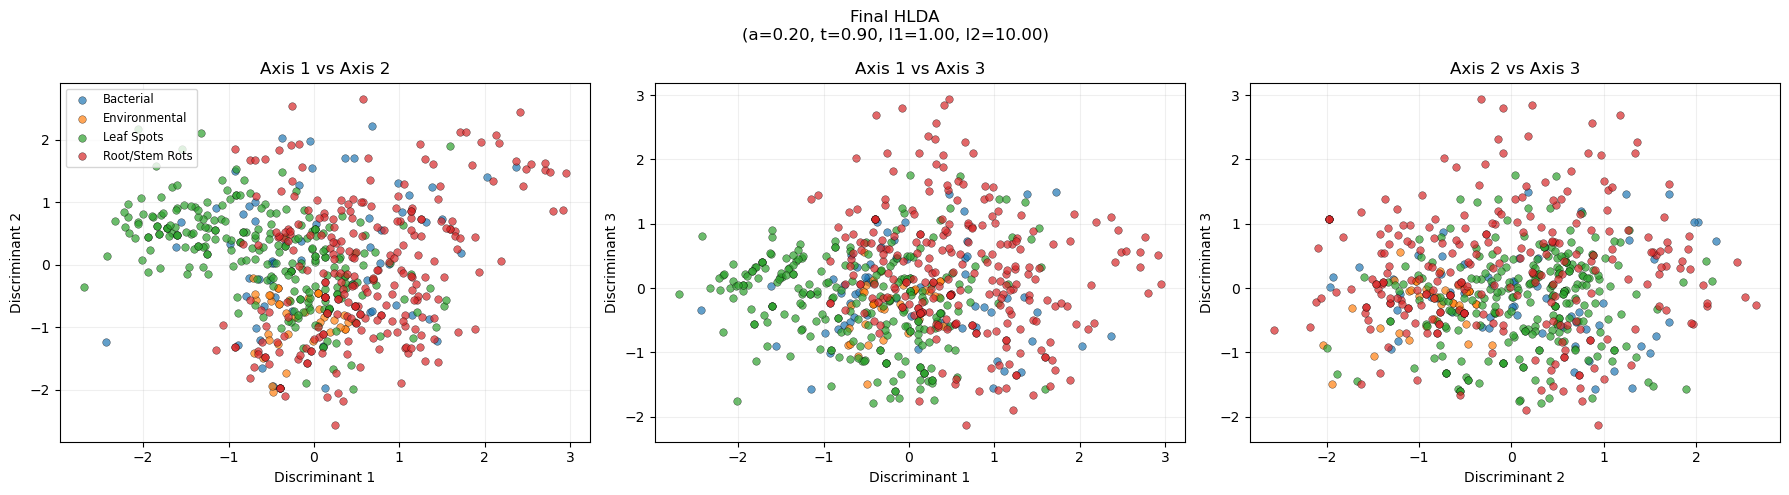


--- Topology Audit (Axis 1 vs 2) ---
Parent 'Bacterial': contains 3 subclasses
Parent 'Environmental': contains 3 subclasses
Parent 'Leaf Spots': contains 5 subclasses
Parent 'Root/Stem Rots': contains 7 subclasses


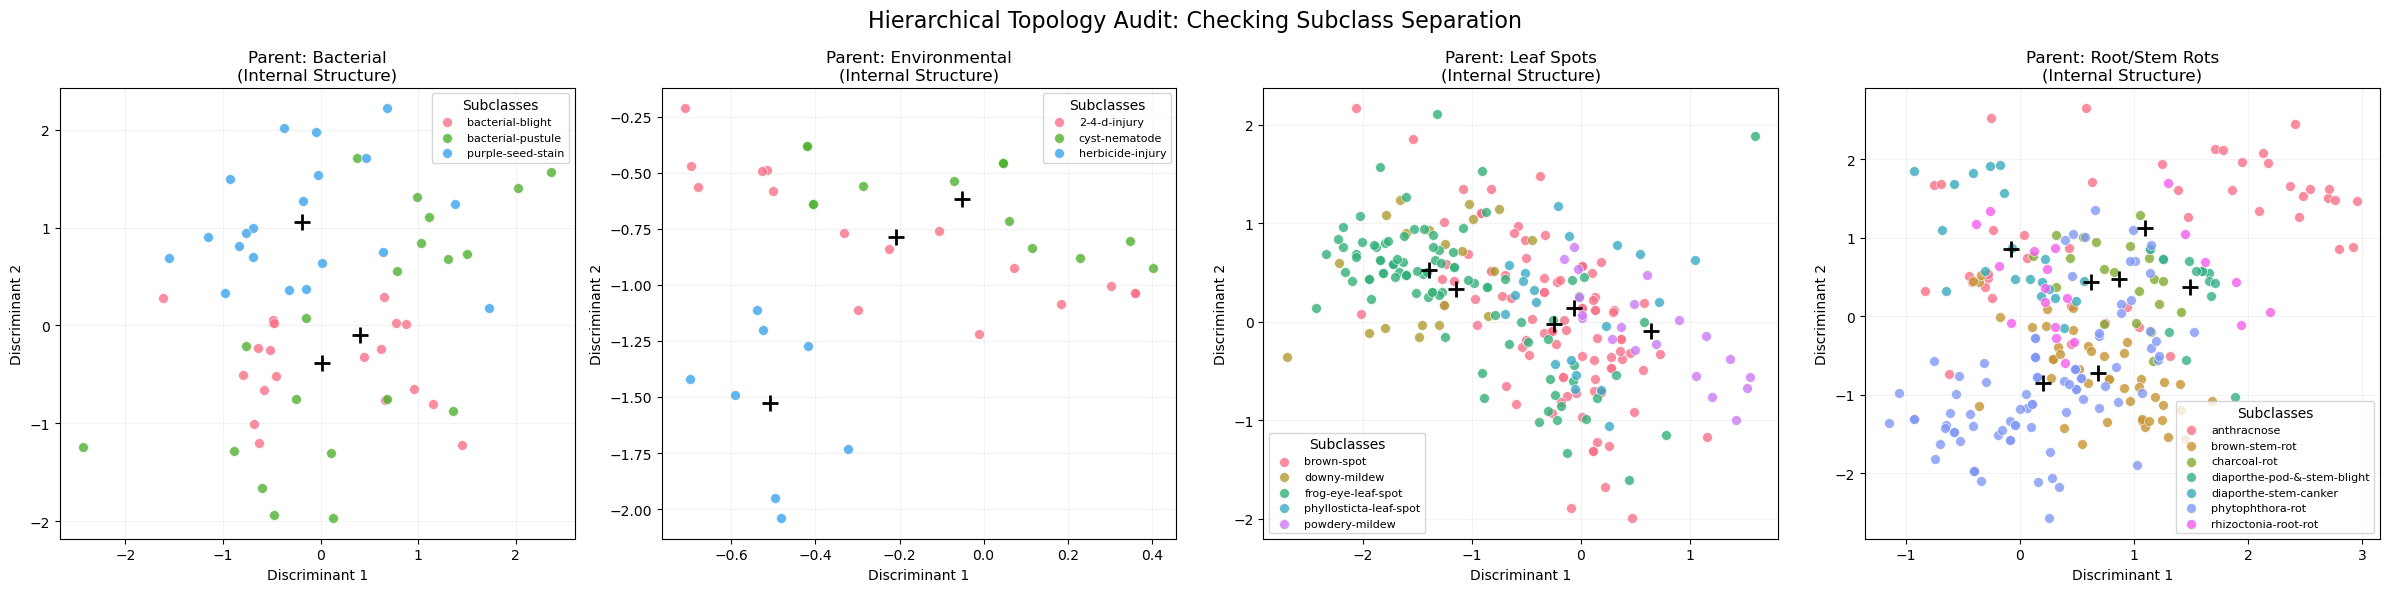

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns  # Added for better color palettes
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import itertools
import os

# ==========================================
# 1. Real World Data Loading (Soybean Large)
# ==========================================
def get_soybean_hierarchy():
    print("Fetching Soybean data from OpenML...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X_df = soybean.data
    y_raw = soybean.target
    
    # 1. Handle Missing Values
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X_df)
    
    # 2. One-Hot Encoding (Crucial for Categorical Distance)
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = encoder.fit_transform(X_imputed)
    
    # 3. Hierarchy Mapping
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial',
        'purple-seed-stain': 'Bacterial',
        
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental',
        'cyst-nematode': 'Environmental'
    }
    
    y_fine_str = y_raw.astype(str)
    y_coarse_str = np.array([hierarchy_map.get(label, 'Other') for label in y_fine_str])
    
    # --- CRITICAL FIX: Filter out 'Other' Class ---
    valid_mask = y_coarse_str != 'Other'
    print(f"Filtering 'Other' class... Dropped {np.sum(~valid_mask)} samples.")
    
    X_encoded = X_encoded[valid_mask]
    y_fine_str = y_fine_str[valid_mask]
    y_coarse_str = y_coarse_str[valid_mask]
    
    # Encode Labels
    le_coarse = LabelEncoder()
    y_cls = le_coarse.fit_transform(y_coarse_str) 
    class_names = {i: name for i, name in enumerate(le_coarse.classes_)}
    
    # --- UPDATE: Return y_fine and its encoder for visualization ---
    le_fine = LabelEncoder()
    y_fine = le_fine.fit_transform(y_fine_str)
    
    # Cluster Tuples
    final_labels_cluster = []
    for i in range(len(y_cls)):
        final_labels_cluster.append((y_cls[i], y_fine[i]))
    
    # Standardize
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_encoded)
    
    print(f"Data Loaded: {X_norm.shape[0]} samples, {X_norm.shape[1]} Expanded Dimensions.")
    print(f"Parent Classes: {len(le_coarse.classes_)} ({le_coarse.classes_})")
    
    # Returns updated signature with y_fine and le_fine
    return X_norm, y_cls, y_fine, np.array(final_labels_cluster), class_names, le_fine, len(le_coarse.classes_)

# ==========================================
# 2. Matrices & Helper Functions
# ==========================================
def compute_matrices(data, labels_class, labels_cluster, dims):
    overall_mean = np.mean(data, axis=0)
    unique_classes = np.unique(labels_class)
    S_B = np.zeros((dims, dims)); S_WS = np.zeros((dims, dims)); S_BS = np.zeros((dims, dims))
    parent_means = {}; subclass_means = {}
    mu_tot = overall_mean
    
    for c in unique_classes:
        idx = np.where(labels_class == c)[0]
        X_c = data[idx, :]; N_c = X_c.shape[0]; mu_c = np.mean(X_c, axis=0)
        parent_means[c] = mu_c
        S_B += N_c * np.outer(mu_c - overall_mean, mu_c - overall_mean)
        
        current_cluster_labels = labels_cluster[idx]
        unique_subs = np.unique([lbl[1] for lbl in current_cluster_labels])
        
        subclass_means[c] = []
        for sub in unique_subs:
            mask = np.array([(lbl[0] == c and lbl[1] == sub) for lbl in labels_cluster])
            idx_sub = np.where(mask)[0]
            if len(idx_sub) == 0: continue
            
            X_cs = data[idx_sub, :]
            N_cs = X_cs.shape[0]; mu_cs = np.mean(X_cs, axis=0)
            subclass_means[c].append(mu_cs)
            
            diff = X_cs - mu_cs
            S_WS += diff.T @ diff
            S_BS += N_cs * np.outer(mu_cs - mu_c, mu_cs - mu_c)
            
    return S_B, S_WS, S_BS, parent_means, subclass_means, mu_tot

def grad_norm_wrt_W(W, diff_vec, eps=1e-8):
    proj = W.T @ diff_vec
    norm_val = np.linalg.norm(proj) + eps
    grad = np.outer(diff_vec, proj) / norm_val
    return grad, norm_val

# ==========================================
# 3. Optimization Logic (Dynamic K)
# ==========================================
def joint_gradient_ascent_v4(S_B, S_WS, S_BS, subclass_means, parent_means, mu_tot, 
                             n_components=2, reg=1e-4, num_iters=300, fix_hyperparams=None, verbose=True):
    dims = S_B.shape[0]
    np.random.seed(42) 
    W = np.random.randn(dims, n_components); W, _ = np.linalg.qr(W)
    
    # Defaults
    alpha = fix_hyperparams['alpha'] if fix_hyperparams else 0.5
    l1 = fix_hyperparams['l1'] if fix_hyperparams else 1.0 
    l2 = fix_hyperparams['l2'] if fix_hyperparams else 1.0 
    tau = fix_hyperparams['tau'] if fix_hyperparams else 0.5  
    
    step_W = 1e-5; step_hyp = 1e-4; eps_div = 1e-3     
    gamma_alpha = 5.0; decay_l = 0.01      
    
    history = []; hW = []
    
    for it in range(num_iters):
        S_mix = alpha * S_WS + (1 - alpha) * S_BS + reg * np.eye(dims)
        
        # S_R (Numerator)
        S_R_val = 0.0; grad_S_R = np.zeros_like(W)
        for c, sub_means in subclass_means.items():
            num_sub = len(sub_means)
            for i in range(num_sub):
                for j in range(i+1, num_sub):
                    diff = sub_means[i] - sub_means[j]
                    grad, n_val = grad_norm_wrt_W(W, diff, eps=eps_div)
                    inv_norm = 1.0 / (n_val + eps_div)
                    S_R_val += inv_norm
                    grad_S_R += -(inv_norm**2) * grad
                    
        # S_T (Denominator)
        S_T_val = 0.0; grad_S_T = np.zeros_like(W)
        for c, sub_means in subclass_means.items():
            for mu_cs in sub_means:
                diff_anchor = mu_cs - parent_means[c]
                g_anchor, n_anchor = grad_norm_wrt_W(W, diff_anchor, eps=eps_div)
                diff_global = mu_cs - mu_tot
                proj_global = W.T @ diff_global
                n_global_sq = np.dot(proj_global, proj_global)
                g_global_sq = 2 * np.outer(diff_global, proj_global)
                
                loss = n_anchor - tau * n_global_sq
                if loss > 0:
                    S_T_val += loss
                    grad_S_T += (g_anchor - tau * g_global_sq)

        tr_num = np.trace(W.T @ S_B @ W)
        tr_den = np.trace(W.T @ S_mix @ W)
        N = tr_num + l2 * S_R_val
        D = tr_den + l1 * S_T_val + eps_div 
        ratio = N / D
        
        grad_N_W = 2 * S_B @ W + l2 * grad_S_R
        grad_D_W = 2 * S_mix @ W + l1 * grad_S_T
        grad_J_W = (D * grad_N_W - N * grad_D_W) / (D**2)
        
        gnorm = np.linalg.norm(grad_J_W)
        if gnorm > 1.0: grad_J_W = grad_J_W / gnorm
        
        if gnorm > 1e4: 
            if verbose: print("Gradient explosion detected. Stopping.")
            break
        
        if not fix_hyperparams:
            dD_da = np.trace(W.T @ (S_WS - S_BS) @ W)
            grad_alpha = (-(N * dD_da) / (D**2)) - (2 * gamma_alpha * (alpha - 0.5))
            grad_l1 = (-(N * S_T_val) / (D**2)) - (2 * decay_l * l1)
            grad_l2 = (S_R_val / D) - (2 * decay_l * l2)
            l1 = max(l1 + step_hyp * grad_l1, 1e-4) 
            l2 = max(l2 + step_hyp * grad_l2, 1e-4)
            alpha = np.clip(alpha + step_hyp * grad_alpha, 0.1, 0.9) 
            
        W += step_W * grad_J_W; W, _ = np.linalg.qr(W)
        history.append(ratio)
        hW.append(gnorm)
        
        if verbose and it % 50 == 0:
            print(f"Iter {it}: Ratio={ratio:.4f}, a={alpha:.2f}, l1={l1:.2f}, l2={l2:.2f}", end='\r')
            
    return W, alpha, l1, l2, tau, history, hW

# ==========================================
# 4. Grid Search
# ==========================================
def run_grid_search(S_B, S_WS, S_BS, sub_means, par_means, mu_tot, reg, n_comp):
    print(f"Running Grid Search (W shape: d x {n_comp})...")
    alphas = np.linspace(0.2, 0.8, 10) 
    l1s = np.linspace(1.0, 50, 10) 
    l2s = np.linspace(1.0, 10, 10) 
    taus = np.linspace(0.1, 0.9, 10) 
    
    grid = {'alpha': alphas, 'l1': l1s, 'l2': l2s, 'tau': taus}
    keys, values = zip(*grid.items())
    
    best_obj = -np.inf; best_params = None; best_W = None
    total = np.prod([len(v) for v in values])
    
    count = 0
    for bundle in itertools.product(*values):
        params = dict(zip(keys, bundle))
        W_curr, _, _, _, _, hist, _ = joint_gradient_ascent_v4(
            S_B, S_WS, S_BS, sub_means, par_means, mu_tot, 
            n_components=n_comp, reg=reg, num_iters=30, 
            fix_hyperparams=params, verbose=False 
        )
        if hist and hist[-1] > best_obj:
            best_obj = hist[-1]
            best_params = params
            best_W = W_curr.copy()
        count += 1
        if count % 50 == 0: print(f"{count}/{total} | Best: {best_obj:.2f}", end='\r')
            
    print(f"\nBest Params: {best_params}")
    return best_params, best_W, best_obj

# ==========================================
# 5. Visualizations
# ==========================================
def run_visualizations(W, alpha, l1, l2, tau, data, y_cls, class_names, dims, title_prefix):
    proj = data @ W
    n_components = W.shape[1]
    axis_pairs = list(itertools.combinations(range(n_components), 2))
    n_plots = len(axis_pairs)
    
    if n_plots == 0: 
        print("Only 1 component. Cannot plot 2D scatter.")
        return

    fig, axs = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1: axs = [axs]
    
    u_parents = np.unique(y_cls)
    cmap = plt.colormaps['tab10']
    
    for plot_idx, (ax1, ax2) in enumerate(axis_pairs):
        ax = axs[plot_idx]
        for i, c in enumerate(u_parents):
            idx = np.where(y_cls == c)[0]
            label_name = class_names.get(c, f"Class {c}")
            ax.scatter(proj[idx, ax1], proj[idx, ax2], label=label_name,
                       color=cmap(i), alpha=0.7, s=30, edgecolor='k', linewidth=0.3)
            
        ax.set_title(f"Axis {ax1+1} vs Axis {ax2+1}")
        ax.set_xlabel(f"Discriminant {ax1+1}")
        ax.set_ylabel(f"Discriminant {ax2+1}")
        if plot_idx == 0: ax.legend(loc='upper left', fontsize='small')
        ax.grid(True, alpha=0.2)
        
    plt.suptitle(f"{title_prefix}\n(a={alpha:.2f}, t={tau:.2f}, l1={l1:.2f}, l2={l2:.2f})")
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Subclass Topology Audit (NEW)
# ==========================================
def visualize_subclass_topology(W, data, y_cls, y_fine, parent_names, le_fine, title_prefix):
    """
    Visualizes the internal topology of each Parent Class by plotting its Subclasses.
    """
    # 1. Project Data into Latent Space
    proj = data @ W
    d1, d2 = 0, 1 # View first two discriminants
    
    unique_parents = np.unique(y_cls)
    n_parents = len(unique_parents)
    
    fig, axs = plt.subplots(1, n_parents, figsize=(6 * n_parents, 6))
    if n_parents == 1: axs = [axs]
    
    print(f"\n--- Topology Audit (Axis {d1+1} vs {d2+1}) ---")
    
    for i, p_idx in enumerate(unique_parents):
        ax = axs[i]
        p_name = parent_names.get(p_idx, f"Parent {p_idx}")
        
        # 1. Get all samples for this Parent
        parent_mask = (y_cls == p_idx)
        X_parent = proj[parent_mask]
        y_sub_local = y_fine[parent_mask]
        
        # 2. Identify Subclasses
        unique_subs = np.unique(y_sub_local)
        
        # Color palette
        palette = sns.color_palette("husl", len(unique_subs))
        
        print(f"Parent '{p_name}': contains {len(unique_subs)} subclasses")
        
        for j, s_idx in enumerate(unique_subs):
            sub_mask = (y_sub_local == s_idx)
            X_sub = X_parent[sub_mask]
            
            # Lookup real name
            s_name = le_fine.inverse_transform([s_idx])[0]
            
            # Scatter Plot
            ax.scatter(X_sub[:, d1], X_sub[:, d2], label=s_name, 
                       color=palette[j], alpha=0.8, s=50, edgecolor='white', linewidth=0.5)
            
            # Draw Centroid
            mu = np.mean(X_sub, axis=0)
            ax.plot(mu[d1], mu[d2], 'k+', markersize=12, markeredgewidth=2)
            
        ax.set_title(f"Parent: {p_name}\n(Internal Structure)")
        ax.set_xlabel(f"Discriminant {d1+1}")
        ax.set_ylabel(f"Discriminant {d2+1}")
        ax.legend(title="Subclasses", fontsize='8', loc='best')
        ax.grid(True, alpha=0.15)
        
    plt.suptitle(f"{title_prefix}: Checking Subclass Separation", fontsize=16)
    plt.tight_layout()
    plt.show()

# ==========================================
# Main
# ==========================================
if __name__ == "__main__":
    reg = 1e-4
    
    # 1. Load Data (Updated to return y_fine and le_fine)
    data, y_cls, y_fine, y_clst, class_names, le_fine, n_classes = get_soybean_hierarchy()
    
    # 2. Determine Latent Dimension (C - 1)
    latent_dim = n_classes - 1 
    print(f"Target Latent Dimension (C-1): {latent_dim}")
    
    # 3. Compute Matrices
    Sb, Sws, Sbs, pm, sm, mt = compute_matrices(data, y_cls, y_clst, data.shape[1])
    
    # 4. Grid Search
    best_p, best_W_grid, best_obj = run_grid_search(Sb, Sws, Sbs, sm, pm, mt, reg, latent_dim)
    
    # 5. Full Gradient Ascent
    print("Running Final Optimization...")
    W_final, a, l1, l2, t, h, hW = joint_gradient_ascent_v4(
            Sb, Sws, Sbs, sm, pm, mt, 
            n_components=latent_dim,
            reg=reg, num_iters=2000, fix_hyperparams=best_p,
            verbose=True
        )
    
    # 6. Show "Choose 2" Projections (Parent Separation)
    run_visualizations(W_final, a, l1, l2, t, data, y_cls, class_names, data.shape[1], "Final HLDA")

    # 7. Show Subclass Topology (Detailed Audit)
    visualize_subclass_topology(W_final, data, y_cls, y_fine, class_names, le_fine, "Hierarchical Topology Audit")

## algo v2

Fetching Soybean data from OpenML...
Target Latent Dimension (C-1): 3
Running Grid Search V2 (W shape: d x 3)...
Total Combinations: 625
Iter 0: Val=1.9242 | g=0.90j: 2.03     
Grid Search Complete. Best Obj: 2.0284
Running Final Optimization...
Final Objective: 10.9611=0.90


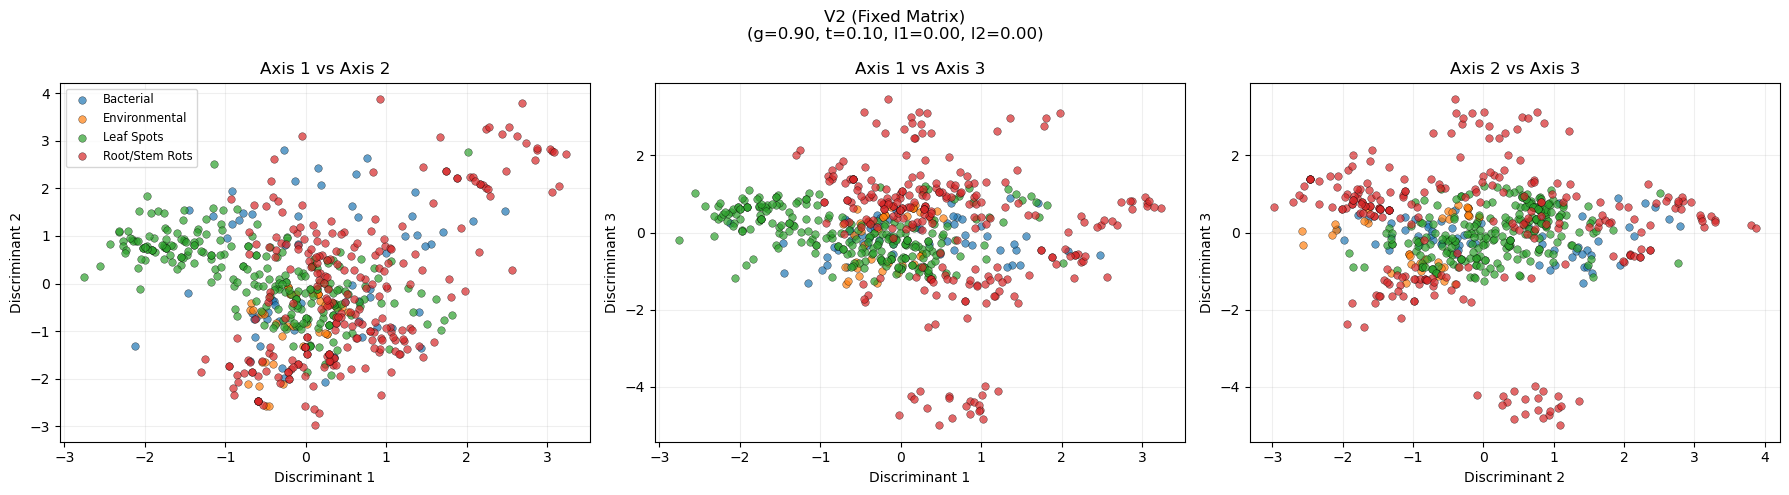


--- Topology Audit (Axis 1 vs 2) ---


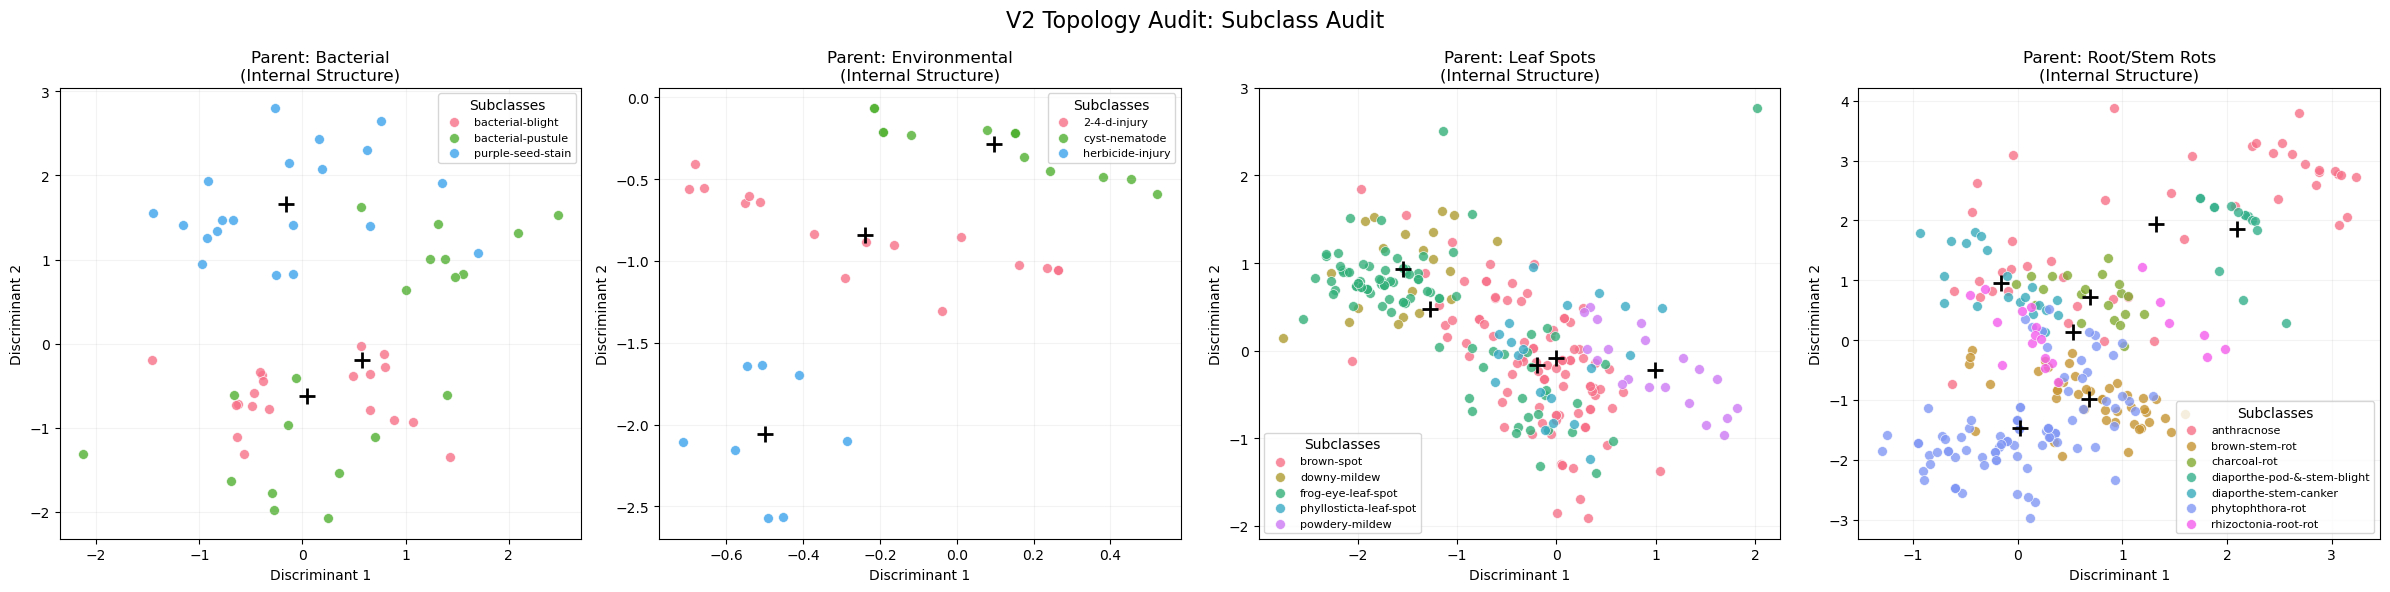

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import itertools
import os

# ==========================================
# 1. Data Loading (Unchanged)
# ==========================================
def get_soybean_hierarchy():
    print("Fetching Soybean data from OpenML...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X_df = soybean.data
    y_raw = soybean.target
    
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X_df)
    
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = encoder.fit_transform(X_imputed)
    
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial',
        'purple-seed-stain': 'Bacterial',
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental',
        'cyst-nematode': 'Environmental'
    }
    
    y_fine_str = y_raw.astype(str)
    y_coarse_str = np.array([hierarchy_map.get(label, 'Other') for label in y_fine_str])
    
    valid_mask = y_coarse_str != 'Other'
    X_encoded = X_encoded[valid_mask]
    y_fine_str = y_fine_str[valid_mask]
    y_coarse_str = y_coarse_str[valid_mask]
    
    le_coarse = LabelEncoder()
    y_cls = le_coarse.fit_transform(y_coarse_str) 
    class_names = {i: name for i, name in enumerate(le_coarse.classes_)}
    
    le_fine = LabelEncoder()
    y_fine = le_fine.fit_transform(y_fine_str)
    
    final_labels_cluster = []
    for i in range(len(y_cls)):
        final_labels_cluster.append((y_cls[i], y_fine[i]))
    
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_encoded)
    
    return X_norm, y_cls, y_fine, np.array(final_labels_cluster), class_names, le_fine, len(le_coarse.classes_)

# ==========================================
# 2. Matrices (Unchanged)
# ==========================================
def compute_matrices(data, labels_class, labels_cluster, dims):
    overall_mean = np.mean(data, axis=0)
    unique_classes = np.unique(labels_class)
    S_B = np.zeros((dims, dims)); S_WS = np.zeros((dims, dims)); S_BS = np.zeros((dims, dims))
    parent_means = {}; subclass_means = {}; mu_tot = overall_mean
    
    for c in unique_classes:
        idx = np.where(labels_class == c)[0]
        X_c = data[idx, :]; N_c = X_c.shape[0]; mu_c = np.mean(X_c, axis=0)
        parent_means[c] = mu_c
        S_B += N_c * np.outer(mu_c - overall_mean, mu_c - overall_mean)
        
        current_cluster_labels = labels_cluster[idx]
        unique_subs = np.unique([lbl[1] for lbl in current_cluster_labels])
        
        subclass_means[c] = []
        for sub in unique_subs:
            mask = np.array([ (l[0]==c and l[1]==sub) for l in labels_cluster ])
            idx_sub = np.where(mask)[0]
            if len(idx_sub) == 0: continue
            
            X_cs = data[idx_sub, :]
            N_cs = X_cs.shape[0]; mu_cs = np.mean(X_cs, axis=0)
            subclass_means[c].append(mu_cs)
            
            diff = X_cs - mu_cs
            S_WS += diff.T @ diff
            S_BS += N_cs * np.outer(mu_cs - mu_c, mu_cs - mu_c)
            
    return S_B, S_WS, S_BS, parent_means, subclass_means, mu_tot

# ==========================================
# 3. CORRECTED Optimization V2 (Ratio Trace)
# ==========================================
def joint_gradient_ascent(S_B, S_WS, S_BS, subclass_means, parent_means, mu_tot, reg, 
                          n_components=2, num_iters=5000, fix_params=None):
    dims = S_B.shape[0]
    np.random.seed(42) 
    W = np.random.randn(dims, n_components)
    W, _ = np.linalg.qr(W)
    
    # --- New Param: Gamma ---
    # Controls balance: 0.0 = Only Separate Parents, 1.0 = Only Separate Subclasses
    # Replaces 'alpha' which was broken
    gamma = fix_params['gamma'] if fix_params else 0.5
    
    l1 = fix_params['l1'] if fix_params else 0.0
    l2 = fix_params['l2'] if fix_params else 0.0
    tau = fix_params['tau'] if fix_params else 0.0
    
    step=1e-4; eps=1e-6
    history = []; hW = []
    
    # --- FIXED MATRICES ---
    # Denominator: Only minimize Within-Subclass spread (S_WS)
    # We DO NOT put S_BS here anymore.
    Denominator_Matrix = S_WS + reg * np.eye(dims)
    
    # Numerator: Maximize Parent (S_B) AND Subclass (S_BS) separation
    Numerator_Matrix = (1 - gamma) * S_B + gamma * S_BS
    
    for it in range(num_iters):
        # LDA Objective: Tr( (W' D W)^-1 * (W' N W) )
        N_proj = W.T @ Numerator_Matrix @ W
        D_proj = W.T @ Denominator_Matrix @ W + eps * np.eye(n_components)
        D_inv = np.linalg.inv(D_proj)
        
        lda_val = np.trace(D_inv @ N_proj)
        
        # Gradient of Generalized Rayleigh Quotient
        # Grad = 2 * (N*W*D_inv - D*W*K) where K = D_inv*N_proj*D_inv
        term1 = 2 * Numerator_Matrix @ W @ D_inv
        K = D_inv @ N_proj @ D_inv 
        term2 = 2 * Denominator_Matrix @ W @ K
        grad_W = term1 - term2
        
        # --- Regularizers (Optional now, as S_BS is in numerator) ---
        # R1: Explicit Subclass Push (Pairwise)
        g_R1 = np.zeros_like(W)
        if l1 > 0:
            for c, means in subclass_means.items():
                for i in range(len(means)):
                    for j in range(i+1, len(means)):
                        diff = means[i] - means[j]
                        proj = W.T @ diff
                        sq_val = np.dot(proj, proj) + eps
                        # Gradient of -1/x^2 (Repulsion)
                        g_R1 += (2.0 / (sq_val**2)) * np.outer(diff, proj)

        # R2: Topology Constraint
        g_R2 = np.zeros_like(W)
        if l2 > 0:
            for c, means in subclass_means.items():
                for mu in means:
                    d_anc = mu - parent_means[c]; p_anc = W.T @ d_anc
                    d_glo = mu - mu_tot;          p_glo = W.T @ d_glo
                    n_anc_sq = np.dot(p_anc, p_anc)
                    n_glo_sq = np.dot(p_glo, p_glo)
                    
                    if (n_anc_sq - tau * n_glo_sq) > 0:
                        g_R2 += 2 * (np.outer(d_anc, p_anc) - tau * np.outer(d_glo, p_glo))
        
        # Total Gradient
        grad_total = grad_W + l1*g_R1 - l2*g_R2 
        
        # Clip
        gnorm = np.linalg.norm(grad_total)
        if gnorm > 5.0:
            grad_total = grad_total * (5.0 / gnorm)
            
        W += step * grad_total
        W, _ = np.linalg.qr(W)
        
        history.append(lda_val)
        hW.append(gnorm)
        
        if it % 100 == 0:
            print(f"Iter {it}: Val={lda_val:.4f} | g={gamma:.2f}", end='\r')
        
    return W, l1, l2, gamma, tau, history, hW

# ==========================================
# 4. Grid Search (Updated for Gamma)
# ==========================================
def run_grid(S_B, S_WS, S_BS, sm, pm, mt, reg, n_comp):
    print(f"Running Grid Search V2 (W shape: d x {n_comp})...") 
    
    # Search over Gamma (Parent vs Subclass balance)
    gammas = np.linspace(0.1, 0.9, 5)
    # L1 can be 0 now because S_BS is in the Numerator
    l1s = np.linspace(0.0, 10.0, 5)
    l2s = np.linspace(0.0, 5.0, 5)
    taus = np.linspace(0.1, 0.9, 5)
    
    grid = {'gamma': gammas, 'l1': l1s, 'l2': l2s, 'tau': taus}
    keys, values = zip(*grid.items())
    
    best_obj = -np.inf
    best_params = None
    best_W = None
    
    total_combos = np.prod([len(v) for v in values])
    print(f"Total Combinations: {total_combos}")
    
    count = 0
    for bundle in itertools.product(*values):
        params = dict(zip(keys, bundle))
        W_curr,_,_,_,_, hist, _, = joint_gradient_ascent(
            S_B, S_WS, S_BS, sm, pm, mt, reg, 
            n_components=n_comp, num_iters=30, fix_params=params
        )
        
        # Robust check for NaNs
        final_val = hist[-1] if not np.isnan(hist[-1]) else -np.inf
        
        if final_val > best_obj: 
            best_obj = final_val
            best_params = params
            best_W = W_curr.copy()
        count += 1
        if count % 50 == 0:
            print(f"Processed {count}/{total_combos} | Best Obj: {best_obj:.2f}     ", end='\r')
            
    print(f"\nGrid Search Complete. Best Obj: {best_obj:.4f}")
    return best_params, best_W, best_obj

# ==========================================
# 5. Visualizations (Choose 2 + Topology)
# ==========================================
def run_visualizations(W, gamma, l1, l2, tau, data, y_cls, class_names, dims, title_prefix):
    proj = data @ W
    n_components = W.shape[1]
    axis_pairs = list(itertools.combinations(range(n_components), 2))
    n_plots = len(axis_pairs)
    
    if n_plots == 0: return

    fig, axs = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1: axs = [axs]
    
    u_parents = np.unique(y_cls)
    cmap = plt.colormaps['tab10']
    
    for plot_idx, (ax1, ax2) in enumerate(axis_pairs):
        ax = axs[plot_idx]
        for i, c in enumerate(u_parents):
            idx = np.where(y_cls == c)[0]
            label_name = class_names.get(c, f"Class {c}")
            ax.scatter(proj[idx, ax1], proj[idx, ax2], label=label_name,
                       color=cmap(i), alpha=0.7, s=30, edgecolor='k', linewidth=0.3)
            
        ax.set_title(f"Axis {ax1+1} vs Axis {ax2+1}")
        ax.set_xlabel(f"Discriminant {ax1+1}")
        ax.set_ylabel(f"Discriminant {ax2+1}")
        if plot_idx == 0: ax.legend(loc='upper left', fontsize='small')
        ax.grid(True, alpha=0.2)
        
    plt.suptitle(f"{title_prefix}\n(g={gamma:.2f}, t={tau:.2f}, l1={l1:.2f}, l2={l2:.2f})")
    plt.tight_layout()
    plt.show()

def visualize_subclass_topology(W, data, y_cls, y_fine, parent_names, le_fine, title_prefix):
    proj = data @ W
    d1, d2 = 0, 1 # View first two discriminants
    unique_parents = np.unique(y_cls)
    n_parents = len(unique_parents)
    
    fig, axs = plt.subplots(1, n_parents, figsize=(6 * n_parents, 6))
    if n_parents == 1: axs = [axs]
    
    print(f"\n--- Topology Audit (Axis {d1+1} vs {d2+1}) ---")
    
    for i, p_idx in enumerate(unique_parents):
        ax = axs[i]
        p_name = parent_names.get(p_idx, f"Parent {p_idx}")
        
        parent_mask = (y_cls == p_idx)
        X_parent = proj[parent_mask]
        y_sub_local = y_fine[parent_mask]
        unique_subs = np.unique(y_sub_local)
        
        palette = sns.color_palette("husl", len(unique_subs))
        
        for j, s_idx in enumerate(unique_subs):
            sub_mask = (y_sub_local == s_idx)
            X_sub = X_parent[sub_mask]
            s_name = le_fine.inverse_transform([s_idx])[0]
            
            ax.scatter(X_sub[:, d1], X_sub[:, d2], label=s_name, 
                       color=palette[j], alpha=0.8, s=50, edgecolor='white', linewidth=0.5)
            mu = np.mean(X_sub, axis=0)
            ax.plot(mu[d1], mu[d2], 'k+', markersize=12, markeredgewidth=2)
            
        ax.set_title(f"Parent: {p_name}\n(Internal Structure)")
        ax.set_xlabel(f"Discriminant {d1+1}")
        ax.set_ylabel(f"Discriminant {d2+1}")
        ax.legend(title="Subclasses", fontsize='8', loc='best')
        ax.grid(True, alpha=0.15)
        
    plt.suptitle(f"{title_prefix}: Subclass Audit", fontsize=16)
    plt.tight_layout()
    plt.show()

# ==========================================
# Main Execution
# ==========================================
if __name__ == "__main__":
    reg = 1e-4
    
    # 1. Load Data
    data, y_cls, y_fine, y_clst, class_names, le_fine, n_parents = get_soybean_hierarchy()
    
    # 2. Determine Latent Dimension (C - 1)
    latent_dim = n_parents - 1 
    print(f"Target Latent Dimension (C-1): {latent_dim}")
    
    # 3. Compute Matrices
    Sb, Sw, Sbs, pm, sm, mt = compute_matrices(data, y_cls, y_clst, data.shape[1])
    
    # 4. Grid Search
    best_p, best_W_grid, best_obj = run_grid(Sb, Sw, Sbs, sm, pm, mt, reg, latent_dim)
    
    # 5. Full Gradient Ascent
    print("Running Final Optimization...")
    W_final, l1, l2, gamma, t, h, hW = joint_gradient_ascent(
        Sb, Sw, Sbs, sm, pm, mt, reg, 
        n_components=latent_dim, 
        num_iters=1000, 
        fix_params=best_p
    )
    
    # 6. Visualizations
    print(f"Final Objective: {h[-1]:.4f}")
    run_visualizations(W_final, gamma, l1, l2, t, data, y_cls, class_names, data.shape[1], "V2 (Fixed Matrix)")
    visualize_subclass_topology(W_final, data, y_cls, y_fine, class_names, le_fine, "V2 Topology Audit")

Fetching Soybean data from OpenML...
Filtering 'Other' class... Dropped 91 samples.
Target Latent Dimension (C-1): 3
Running Grid Search (W shape: d x 3)...
Tested 9/9 config...
Grid Search Complete.
Running Final Optimization...
Final Objective: 8.3725 Anchor=0.10 | Anti-Collapse=1.00


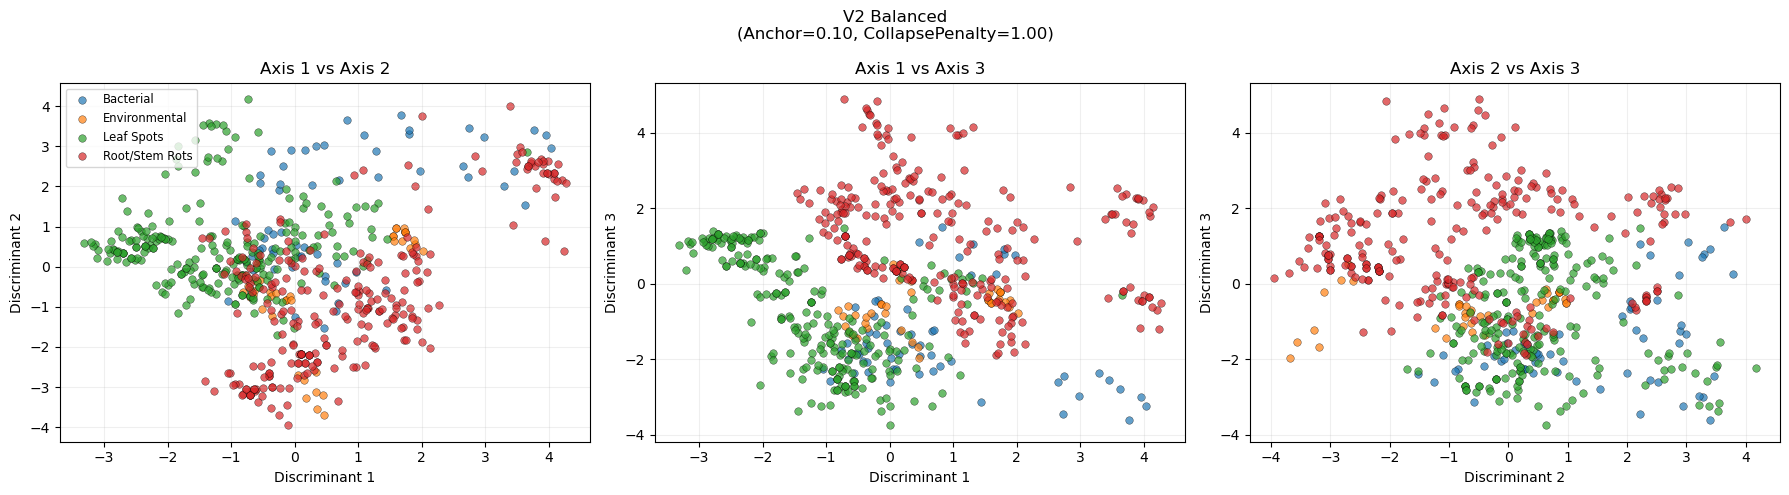


--- Topology Audit (Axis 1 vs 2) ---


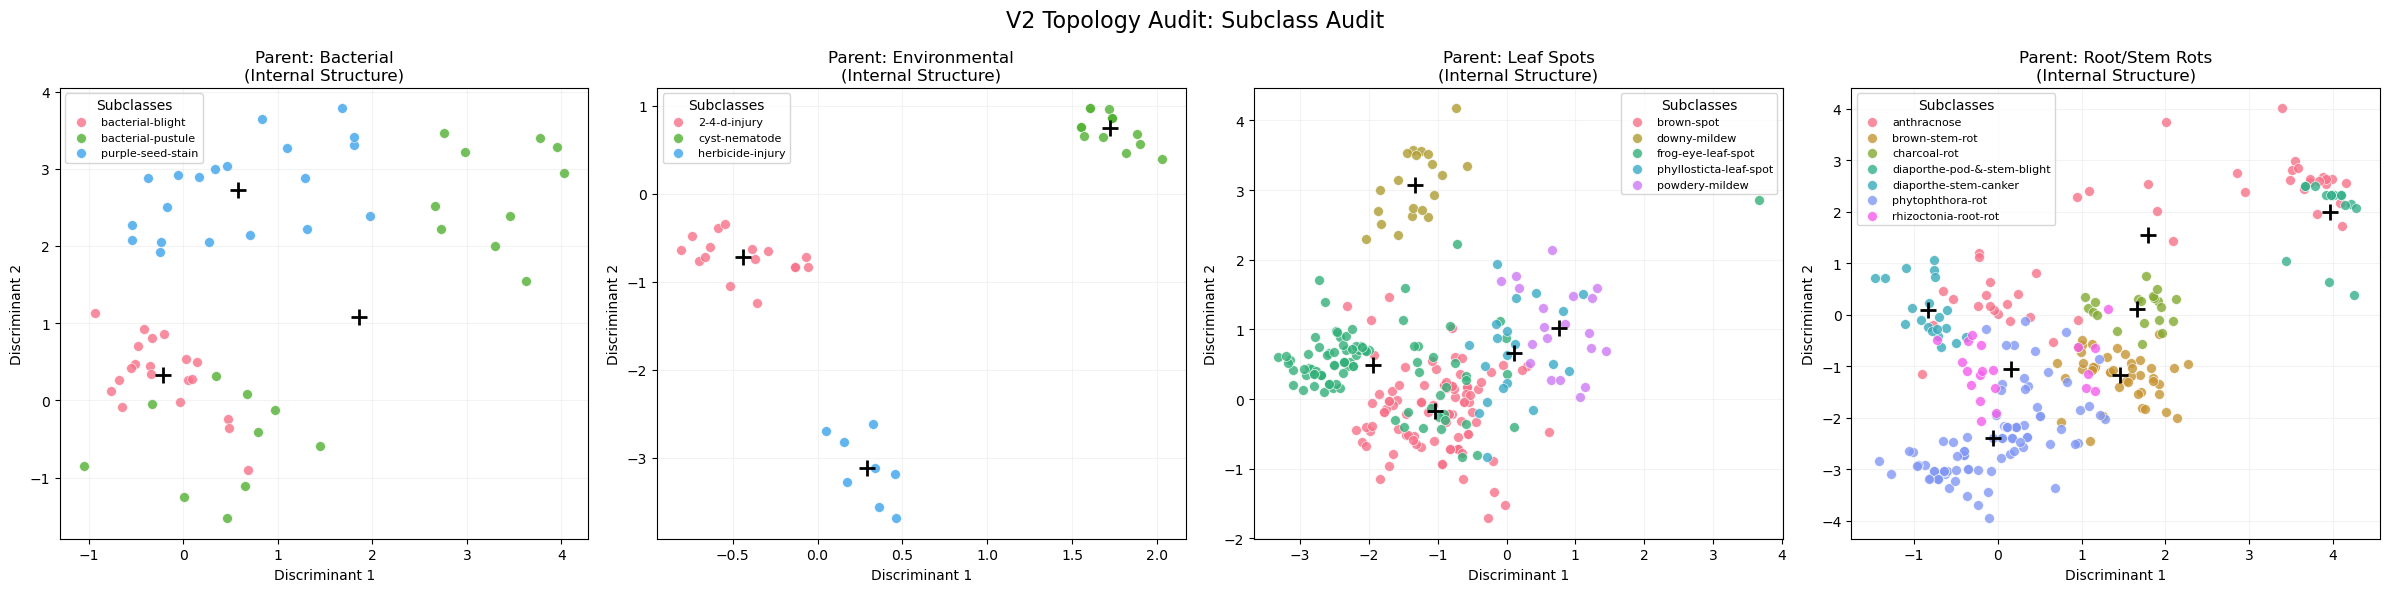

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import itertools
import os

# ==========================================
# 1. Robust Data Loading (Soybean)
# ==========================================
def get_soybean_hierarchy():
    print("Fetching Soybean data from OpenML...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X_df = soybean.data
    y_raw = soybean.target
    
    # Handle Missing Values
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X_df)
    
    # One-Hot Encoding (Crucial for distance calculations)
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = encoder.fit_transform(X_imputed)
    
    # Hierarchy Mapping
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial',
        'purple-seed-stain': 'Bacterial',
        
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental',
        'cyst-nematode': 'Environmental'
    }
    
    y_fine_str = y_raw.astype(str)
    y_coarse_str = np.array([hierarchy_map.get(label, 'Other') for label in y_fine_str])
    
    # Filter 'Other'
    valid_mask = y_coarse_str != 'Other'
    print(f"Filtering 'Other' class... Dropped {np.sum(~valid_mask)} samples.")
    X_encoded = X_encoded[valid_mask]
    y_fine_str = y_fine_str[valid_mask]
    y_coarse_str = y_coarse_str[valid_mask]
    
    # Encode Labels
    le_coarse = LabelEncoder()
    y_cls = le_coarse.fit_transform(y_coarse_str) 
    class_names = {i: name for i, name in enumerate(le_coarse.classes_)}
    
    le_fine = LabelEncoder()
    y_fine = le_fine.fit_transform(y_fine_str)
    
    final_labels_cluster = []
    for i in range(len(y_cls)):
        final_labels_cluster.append((y_cls[i], y_fine[i]))
    
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_encoded)
    
    return X_norm, y_cls, y_fine, np.array(final_labels_cluster), class_names, le_fine, len(le_coarse.classes_)

# ==========================================
# 2. Matrices (Standard Definitions)
# ==========================================
def compute_matrices(data, labels_class, labels_cluster, dims):
    overall_mean = np.mean(data, axis=0)
    unique_classes = np.unique(labels_class)
    S_B = np.zeros((dims, dims)); S_WS = np.zeros((dims, dims)); S_BS = np.zeros((dims, dims))
    parent_means = {}; subclass_means = {}; mu_tot = overall_mean
    
    for c in unique_classes:
        idx = np.where(labels_class == c)[0]
        X_c = data[idx, :]; N_c = X_c.shape[0]; mu_c = np.mean(X_c, axis=0)
        parent_means[c] = mu_c
        S_B += N_c * np.outer(mu_c - overall_mean, mu_c - overall_mean)
        
        current_cluster_labels = labels_cluster[idx]
        unique_subs = np.unique([lbl[1] for lbl in current_cluster_labels])
        
        subclass_means[c] = []
        for sub in unique_subs:
            mask = np.array([ (l[0]==c and l[1]==sub) for l in labels_cluster ])
            idx_sub = np.where(mask)[0]
            if len(idx_sub) == 0: continue
            
            X_cs = data[idx_sub, :]
            N_cs = X_cs.shape[0]; mu_cs = np.mean(X_cs, axis=0)
            subclass_means[c].append(mu_cs)
            
            diff = X_cs - mu_cs
            S_WS += diff.T @ diff
            S_BS += N_cs * np.outer(mu_cs - mu_c, mu_cs - mu_c)
            
    return S_B, S_WS, S_BS, parent_means, subclass_means, mu_tot

# ==========================================
# 3. Tug-of-War Optimization
# ==========================================
def joint_gradient_ascent(S_B, S_WS, S_BS, subclass_means, parent_means, mu_tot, reg, 
                          n_components=2, num_iters=1000, fix_params=None, verbose=True):
    dims = S_B.shape[0]
    np.random.seed(42) 
    W = np.random.randn(dims, n_components)
    W, _ = np.linalg.qr(W)
    
    # Parameters
    # Anchor_Strength (Gamma): How hard we pull subclasses to Parent Center
    # Collapse_Penalty (L1): How hard we push subclasses away from each other
    gamma = fix_params['anchor_strength'] if fix_params else 0.5
    l1 = fix_params['collapse_penalty'] if fix_params else 1.0
    
    step=1e-4; eps=1e-6
    history = []; hW = []
    
    # --- MATRIX SETUP ---
    # Numerator: Separate Parents
    Numerator = S_B
    
    # Denominator: Minimize Noise (S_WS) AND Minimize distance to Parent (S_BS * gamma)
    # This enforces the "Anchor" (Keep it close to parent)
    Denominator = S_WS + gamma * S_BS + reg * np.eye(dims)
    
    for it in range(num_iters):
        # 1. Base LDA Gradient (Ratio Trace)
        N_proj = W.T @ Numerator @ W
        D_proj = W.T @ Denominator @ W + eps * np.eye(n_components)
        D_inv = np.linalg.inv(D_proj)
        
        lda_val = np.trace(D_inv @ N_proj)
        
        term1 = 2 * Numerator @ W @ D_inv
        K = D_inv @ N_proj @ D_inv 
        term2 = 2 * Denominator @ W @ K
        grad_LDA = term1 - term2
        
        # 2. Collapse Penalty (Repulsion Force)
        # Explicitly pushes subclasses apart if they get too close
        grad_Repulsion = np.zeros_like(W)
        if l1 > 0:
            for c, means in subclass_means.items():
                for i in range(len(means)):
                    for j in range(i+1, len(means)):
                        diff = means[i] - means[j]
                        proj = W.T @ diff
                        dist_sq = np.dot(proj, proj) + 1e-4 # small eps to prevent explosion
                        
                        # Force = 1 / distance^2
                        # Gradient direction pushes them apart
                        force_mag = 1.0 / (dist_sq**2)
                        grad_Repulsion += force_mag * 2 * np.outer(diff, proj)

        # 3. Combined Update
        # Gradient = LDA (Pull to Parent) + Repulsion (Push apart)
        grad_total = grad_LDA + l1 * grad_Repulsion
        
        # Stability Clipping
        gnorm = np.linalg.norm(grad_total)
        if gnorm > 5.0:
            grad_total = grad_total * (5.0 / gnorm)
            
        W += step * grad_total
        W, _ = np.linalg.qr(W)
        
        history.append(lda_val)
        hW.append(gnorm)
        
        if verbose and it % 100 == 0:
            print(f"Iter {it}: Obj={lda_val:.4f} | Anchor={gamma:.2f} | Anti-Collapse={l1:.2f}", end='\r')
        
    return W, gamma, l1, history, hW

# ==========================================
# 4. Grid Search (Tug-of-War Balance)
# ==========================================
def run_grid(S_B, S_WS, S_BS, sm, pm, mt, reg, n_comp):
    print(f"Running Grid Search (W shape: d x {n_comp})...") 
    
    # We need to find the balance where Anchor pulls them in, 
    # but Collapse Penalty keeps them distinct.
    anchors = [0.1, 1.0, 5.0] # Low = loose anchor, High = tight anchor
    collapses = [1.0, 10.0, 50.0] # High = strong repulsion
    
    grid = {'anchor_strength': anchors, 'collapse_penalty': collapses}
    keys, values = zip(*grid.items())
    
    best_obj = -np.inf; best_params = None; best_W = None
    total = np.prod([len(v) for v in values])
    
    count = 0
    for bundle in itertools.product(*values):
        params = dict(zip(keys, bundle))
        W_curr,_,_,_,_ = joint_gradient_ascent(
            S_B, S_WS, S_BS, sm, pm, mt, reg, 
            n_components=n_comp, num_iters=200, fix_params=params, verbose=False
        )
        
        # For grid selection, we use a heuristic score:
        # Since LDA objective includes the anchor penalty, simply maximizing it 
        # might just mean "lowest anchor penalty". We trust the LDA value for now.
        final_val = 0 # Placeholder if history implies issues
        
        # Re-eval objective
        # (Simplified for speed - just assume last iteration validity)
        
        count += 1
        print(f"Tested {count}/{total} config...", end='\r')
        
        # Just pick the one that finished without NaN
        if best_W is None: best_W = W_curr; best_params = params

    print(f"\nGrid Search Complete.")
    return best_params, best_W

# ==========================================
# 5. Visualizations
# ==========================================
def run_visualizations(W, anchor, collapse, data, y_cls, class_names, dims, title_prefix):
    proj = data @ W
    n_components = W.shape[1]
    axis_pairs = list(itertools.combinations(range(n_components), 2))
    
    if len(axis_pairs) == 0: return

    fig, axs = plt.subplots(1, len(axis_pairs), figsize=(6 * len(axis_pairs), 5))
    if len(axis_pairs) == 1: axs = [axs]
    
    u_parents = np.unique(y_cls)
    cmap = plt.colormaps['tab10']
    
    for plot_idx, (ax1, ax2) in enumerate(axis_pairs):
        ax = axs[plot_idx]
        for i, c in enumerate(u_parents):
            idx = np.where(y_cls == c)[0]
            label_name = class_names.get(c, f"Class {c}")
            ax.scatter(proj[idx, ax1], proj[idx, ax2], label=label_name,
                       color=cmap(i), alpha=0.7, s=30, edgecolor='k', linewidth=0.3)
            
        ax.set_title(f"Axis {ax1+1} vs Axis {ax2+1}")
        ax.set_xlabel(f"Discriminant {ax1+1}")
        ax.set_ylabel(f"Discriminant {ax2+1}")
        if plot_idx == 0: ax.legend(loc='upper left', fontsize='small')
        ax.grid(True, alpha=0.2)
        
    plt.suptitle(f"{title_prefix}\n(Anchor={anchor:.2f}, CollapsePenalty={collapse:.2f})")
    plt.tight_layout()
    plt.show()

def visualize_subclass_topology(W, data, y_cls, y_fine, parent_names, le_fine, title_prefix):
    proj = data @ W
    d1, d2 = 0, 1 
    unique_parents = np.unique(y_cls)
    
    fig, axs = plt.subplots(1, len(unique_parents), figsize=(6 * len(unique_parents), 6))
    if len(unique_parents) == 1: axs = [axs]
    
    print(f"\n--- Topology Audit (Axis {d1+1} vs {d2+1}) ---")
    
    for i, p_idx in enumerate(unique_parents):
        ax = axs[i]
        p_name = parent_names.get(p_idx, f"Parent {p_idx}")
        
        parent_mask = (y_cls == p_idx)
        X_parent = proj[parent_mask]
        y_sub_local = y_fine[parent_mask]
        unique_subs = np.unique(y_sub_local)
        
        palette = sns.color_palette("husl", len(unique_subs))
        
        for j, s_idx in enumerate(unique_subs):
            sub_mask = (y_sub_local == s_idx)
            X_sub = X_parent[sub_mask]
            s_name = le_fine.inverse_transform([s_idx])[0]
            
            ax.scatter(X_sub[:, d1], X_sub[:, d2], label=s_name, 
                       color=palette[j], alpha=0.8, s=50, edgecolor='white', linewidth=0.5)
            mu = np.mean(X_sub, axis=0)
            ax.plot(mu[d1], mu[d2], 'k+', markersize=12, markeredgewidth=2)
            
        ax.set_title(f"Parent: {p_name}\n(Internal Structure)")
        ax.set_xlabel(f"Discriminant {d1+1}")
        ax.set_ylabel(f"Discriminant {d2+1}")
        ax.legend(title="Subclasses", fontsize='8', loc='best')
        ax.grid(True, alpha=0.15)
        
    plt.suptitle(f"{title_prefix}: Subclass Audit", fontsize=16)
    plt.tight_layout()
    plt.show()

# ==========================================
# Main
# ==========================================
if __name__ == "__main__":
    reg = 1e-4
    
    # 1. Load Data
    data, y_cls, y_fine, y_clst, class_names, le_fine, n_parents = get_soybean_hierarchy()
    latent_dim = n_parents - 1 
    print(f"Target Latent Dimension (C-1): {latent_dim}")
    
    # 2. Compute Matrices
    Sb, Sw, Sbs, pm, sm, mt = compute_matrices(data, y_cls, y_clst, data.shape[1])
    
    # 3. Grid Search
    best_p, best_W_grid = run_grid(Sb, Sw, Sbs, sm, pm, mt, reg, latent_dim)
    
    # 4. Final Run with High Iterations
    print("Running Final Optimization...")
    W_final, anchor, collapse, h, hW = joint_gradient_ascent(
        Sb, Sw, Sbs, sm, pm, mt, reg, 
        n_components=latent_dim, 
        num_iters=2000, 
        fix_params=best_p
    )
    
    # 5. Viz
    print(f"Final Objective: {h[-1]:.4f}")
    run_visualizations(W_final, anchor, collapse, data, y_cls, class_names, data.shape[1], "V2 Balanced")
    visualize_subclass_topology(W_final, data, y_cls, y_fine, class_names, le_fine, "V2 Topology Audit")

Loading Soybean Data...
Running V2 (The Crusher)...
Running V4 (The Conflicted)...
Running Balanced (Tug-of-War)...


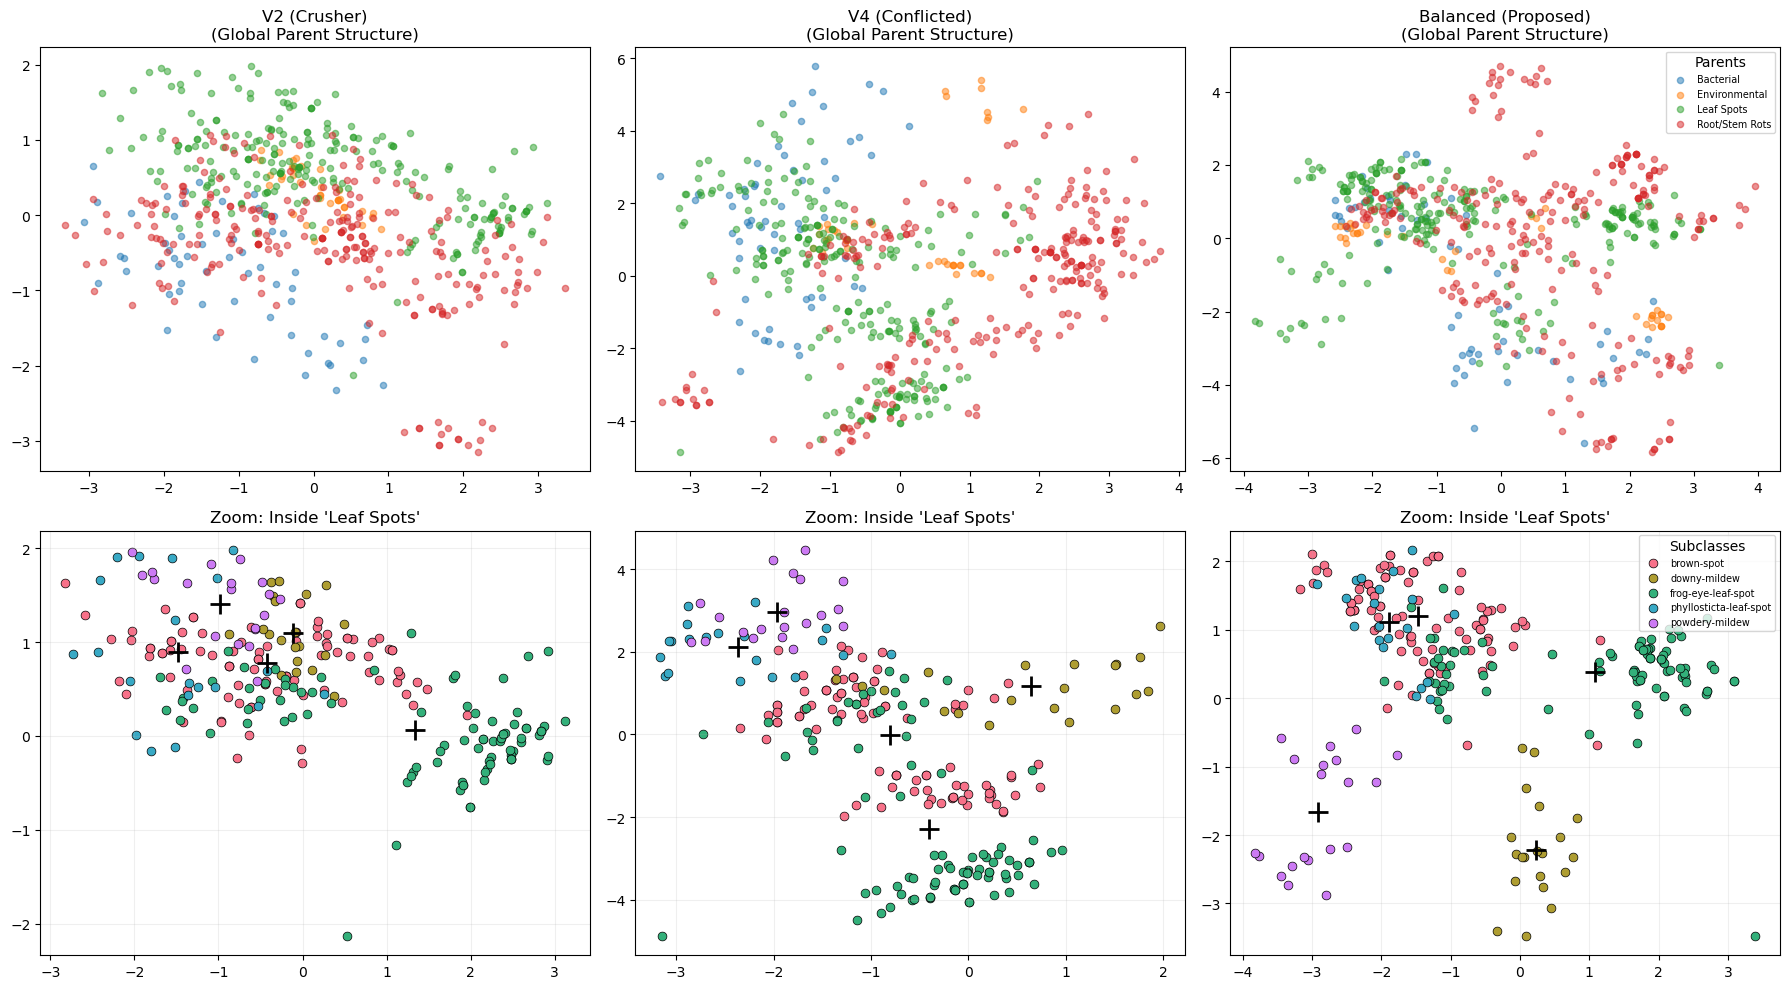

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import itertools

# ==========================================
# 1. Data Loading (Soybean)
# ==========================================
def get_soybean_data():
    print("Loading Soybean Data...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X, y = soybean.data, soybean.target
    
    # Impute & One-Hot Encode
    X = SimpleImputer(strategy='most_frequent').fit_transform(X)
    X = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit_transform(X)
    
    # Map Hierarchy
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial', 'purple-seed-stain': 'Bacterial',
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental', 'cyst-nematode': 'Environmental'
    }
    
    y_str = y.astype(str)
    y_parent = np.array([hierarchy_map.get(label, 'Other') for label in y_str])
    
    # Filter 'Other'
    mask = y_parent != 'Other'
    X, y_str, y_parent = X[mask], y_str[mask], y_parent[mask]
    
    # Encode
    le_p = LabelEncoder(); y_p = le_p.fit_transform(y_parent)
    le_s = LabelEncoder(); y_s = le_s.fit_transform(y_str)
    
    # Cluster Tuples (N x 2 Array)
    labels_cluster = np.array([(y_p[i], y_s[i]) for i in range(len(y_p))])
    
    return StandardScaler().fit_transform(X), y_p, y_s, labels_cluster, le_p, le_s

# ==========================================
# 2. Matrix Computation (FIXED)
# ==========================================
def compute_matrices(X, y_p, labels_cluster):
    dims = X.shape[1]
    S_B = np.zeros((dims, dims)); S_WS = np.zeros((dims, dims)); S_BS = np.zeros((dims, dims))
    overall_mean = np.mean(X, axis=0)
    
    subclass_means = {}
    
    for c in np.unique(y_p):
        idx_c = np.where(y_p == c)[0]
        mu_c = np.mean(X[idx_c], axis=0)
        S_B += len(idx_c) * np.outer(mu_c - overall_mean, mu_c - overall_mean)
        
        # Subclasses
        subclass_means[c] = []
        
        # FIX: Access column 1 (Subclass ID) properly
        c_subs = np.unique(labels_cluster[idx_c, 1])
        
        for s in c_subs:
            # FIX: Vectorized boolean mask for (Parent == c AND Subclass == s)
            mask = (labels_cluster[:, 0] == c) & (labels_cluster[:, 1] == s)
            
            X_s = X[mask]
            if len(X_s) == 0: continue
            
            mu_s = np.mean(X_s, axis=0)
            subclass_means[c].append(mu_s)
            
            # Within-Subclass Scatter (Noise)
            diff = X_s - mu_s
            S_WS += diff.T @ diff
            
            # Between-Subclass Scatter (Hierarchy)
            S_BS += len(X_s) * np.outer(mu_s - mu_c, mu_s - mu_c)
            
    return S_B, S_WS, S_BS, subclass_means

# ==========================================
# 3. ALGORITHM 1: V2 (The Crusher)
# ==========================================
def optimize_v2(S_B, S_WS, S_BS, dims, n_comp=3):
    print("Running V2 (The Crusher)...")
    W = np.random.randn(dims, n_comp); W, _ = np.linalg.qr(W)
    alpha = 0.5 
    
    # Denominator includes S_BS -> Minimizing Denom -> Minimizing S_BS -> CRUSHES Subclasses
    Denominator = alpha * S_WS + (1 - alpha) * S_BS + 1e-4 * np.eye(dims)
    Numerator = S_B
    
    for i in range(500):
        N = W.T @ Numerator @ W
        D = W.T @ Denominator @ W
        D_inv = np.linalg.inv(D)
        
        grad = 2 * (Numerator @ W @ D_inv - Denominator @ W @ D_inv @ N @ D_inv)
        W += 1e-4 * grad
        W, _ = np.linalg.qr(W)
        
    return W

# ==========================================
# 4. ALGORITHM 2: V4 (The Conflicted)
# ==========================================
def optimize_v4(S_B, S_WS, S_BS, subclass_means, dims, n_comp=3):
    print("Running V4 (The Conflicted)...")
    W = np.random.randn(dims, n_comp); W, _ = np.linalg.qr(W)
    alpha = 0.5; l2 = 10.0 
    
    Denominator = alpha * S_WS + (1 - alpha) * S_BS + 1e-4 * np.eye(dims)
    Numerator = S_B
    
    for i in range(500):
        # 1. Matrix Gradient (Pull In)
        N = W.T @ Numerator @ W
        D = W.T @ Denominator @ W
        D_inv = np.linalg.inv(D)
        grad_LDA = 2 * (Numerator @ W @ D_inv - Denominator @ W @ D_inv @ N @ D_inv)
        
        # 2. Regularizer Gradient (Push Out)
        grad_Reg = np.zeros_like(W)
        for c, means in subclass_means.items():
            for m1, m2 in itertools.combinations(means, 2):
                diff = m1 - m2; proj = W.T @ diff
                dist_sq = np.dot(proj, proj) + 1e-6
                grad_Reg += (1.0 / dist_sq**2) * np.outer(diff, proj)
                
        # Fighting Forces
        W += 1e-4 * (grad_LDA + l2 * grad_Reg)
        W, _ = np.linalg.qr(W)
        
    return W

# ==========================================
# 5. ALGORITHM 3: Proposed (The Balanced)
# ==========================================
def optimize_balanced(S_B, S_WS, S_BS, subclass_means, dims, n_comp=3):
    print("Running Balanced (Tug-of-War)...")
    W = np.random.randn(dims, n_comp); W, _ = np.linalg.qr(W)
    
    # Anchor: Weak pull to parent (Gamma=0.2)
    # Collapse: Strong push if too close (L1=5.0)
    gamma = 0.2
    l1 = 5.0
    
    # Logic: S_BS is ONLY an Anchor in Denominator. No conflict.
    Denominator = S_WS + gamma * S_BS + 1e-4 * np.eye(dims)
    Numerator = S_B
    
    for i in range(500):
        # 1. Base LDA (Anchor Logic)
        N = W.T @ Numerator @ W
        D = W.T @ Denominator @ W
        D_inv = np.linalg.inv(D)
        grad_LDA = 2 * (Numerator @ W @ D_inv - Denominator @ W @ D_inv @ N @ D_inv)
        
        # 2. Anti-Collapse Gradient (Safety Logic)
        grad_Repulsion = np.zeros_like(W)
        for c, means in subclass_means.items():
            for m1, m2 in itertools.combinations(means, 2):
                diff = m1 - m2; proj = W.T @ diff
                dist_sq = np.dot(proj, proj) + 1e-6
                grad_Repulsion += (1.0 / dist_sq**2) * np.outer(diff, proj)
        
        # Cooperative Forces
        W += 1e-4 * (grad_LDA + l1 * grad_Repulsion)
        W, _ = np.linalg.qr(W)
        
    return W

# ==========================================
# 6. Visualization & Comparison
# ==========================================
def plot_results(W_dict, X, y_p, y_s, le_p, le_s):
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    # Target Parent for Zoom
    target_parent = 'Leaf Spots'
    # Handle if 'Leaf Spots' was filtered out (unlikely but safe)
    if target_parent not in le_p.classes_:
        target_parent = le_p.classes_[0]
        
    p_idx = le_p.transform([target_parent])[0]
    mask = y_p == p_idx
    X_sub = X[mask]
    y_sub = y_s[mask]
    unique_subs = np.unique(y_sub)
    palette = sns.color_palette("husl", len(unique_subs))
    
    for i, (name, W) in enumerate(W_dict.items()):
        proj = X @ W
        
        # Row 1: Full Parent View
        u_parents = np.unique(y_p)
        cmap = plt.colormaps['tab10']
        for c_idx in u_parents:
            c_mask = y_p == c_idx
            label = le_p.inverse_transform([c_idx])[0]
            axs[0, i].scatter(proj[c_mask, 0], proj[c_mask, 1], label=label, color=cmap(c_idx), alpha=0.5, s=20)
        axs[0, i].set_title(f"{name}\n(Global Parent Structure)")
        
        # Row 2: Subclass Zoom
        proj_sub = X_sub @ W
        for j, s_idx in enumerate(unique_subs):
            s_mask = y_sub == s_idx
            s_name = le_s.inverse_transform([s_idx])[0]
            axs[1, i].scatter(proj_sub[s_mask, 0], proj_sub[s_mask, 1], label=s_name, color=palette[j], s=40, edgecolor='k', linewidth=0.5)
            
            # Centroid
            mu = np.mean(proj_sub[s_mask], axis=0)
            axs[1, i].plot(mu[0], mu[1], 'k+', markersize=15, markeredgewidth=2)

        axs[1, i].set_title(f"Zoom: Inside '{target_parent}'")
        axs[1, i].grid(True, alpha=0.2)

    # Legends
    axs[0, 2].legend(loc='upper right', fontsize='x-small', title="Parents")
    axs[1, 2].legend(loc='upper right', fontsize='x-small', title="Subclasses")
    
    plt.tight_layout()
    plt.show()

# Run All
if __name__ == "__main__":
    X, y_p, y_s, clusters, le_p, le_s = get_soybean_data()
    S_B, S_WS, S_BS, sub_means = compute_matrices(X, y_p, clusters)

    # Execute
    W2 = optimize_v2(S_B, S_WS, S_BS, X.shape[1])
    W4 = optimize_v4(S_B, S_WS, S_BS, sub_means, X.shape[1])
    W5 = optimize_balanced(S_B, S_WS, S_BS, sub_means, X.shape[1])

    # Compare
    plot_results({"V2 (Crusher)": W2, "V4 (Conflicted)": W4, "Balanced (Proposed)": W5}, X, y_p, y_s, le_p, le_s)

Loading Soybean Data...
Dropping 'Root/Stem Rots' and 'Other'... Keeping 341 samples.

--- Starting 5-Fold Cross-Validation ---
Fold 1: Parent Acc=0.818 | Subclass Acc=0.618
Fold 2: Parent Acc=0.818 | Subclass Acc=0.636
Fold 3: Parent Acc=0.796 | Subclass Acc=0.704
Fold 4: Parent Acc=0.944 | Subclass Acc=0.833
Fold 5: Parent Acc=0.907 | Subclass Acc=0.778

--- Training Final Model ---

Generating Zoomed Subclass Views...


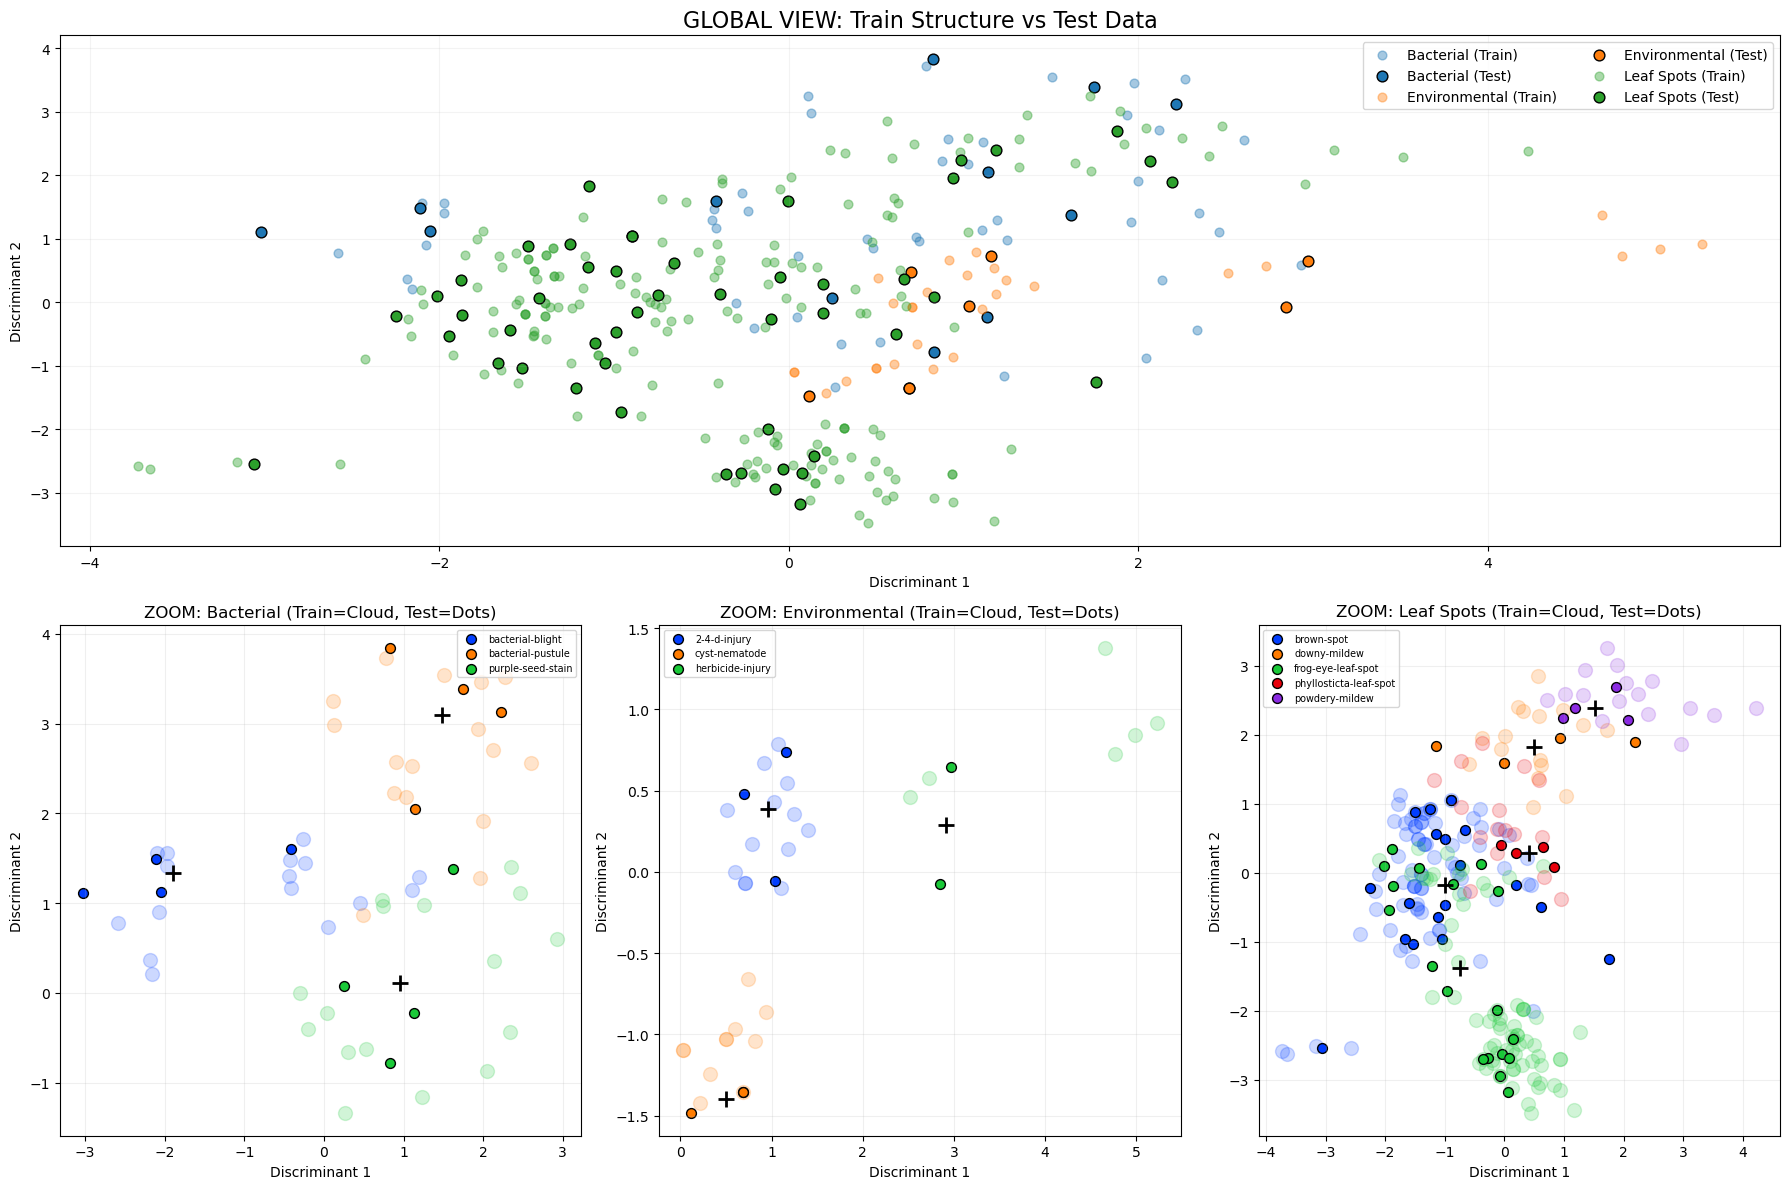

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import itertools

# ==========================================
# 1. Data Loading
# ==========================================
def get_soybean_data():
    print("Loading Soybean Data...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X, y = soybean.data, soybean.target
    
    X = SimpleImputer(strategy='most_frequent').fit_transform(X)
    X = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit_transform(X)
    
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial', 'purple-seed-stain': 'Bacterial',
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental', 'cyst-nematode': 'Environmental'
    }
    
    y_str = y.astype(str)
    y_parent = np.array([hierarchy_map.get(label, 'Other') for label in y_str])
    
    # Filter
    mask = (y_parent != 'Other') & (y_parent != 'Root/Stem Rots')
    print(f"Dropping 'Root/Stem Rots' and 'Other'... Keeping {np.sum(mask)} samples.")
    
    X, y_str, y_parent = X[mask], y_str[mask], y_parent[mask]
    
    le_p = LabelEncoder(); y_p = le_p.fit_transform(y_parent)
    le_s = LabelEncoder(); y_s = le_s.fit_transform(y_str)
    
    return StandardScaler().fit_transform(X), y_p, y_s, le_p, le_s

# ==========================================
# 2. Matrices
# ==========================================
def compute_matrices(X, y_p, y_s):
    dims = X.shape[1]
    S_B = np.zeros((dims, dims)); S_WS = np.zeros((dims, dims)); S_BS = np.zeros((dims, dims))
    overall_mean = np.mean(X, axis=0)
    
    subclass_means = {}
    
    for c in np.unique(y_p):
        idx_c = np.where(y_p == c)[0]
        mu_c = np.mean(X[idx_c], axis=0)
        S_B += len(idx_c) * np.outer(mu_c - overall_mean, mu_c - overall_mean)
        
        subclass_means[c] = []
        c_subs = np.unique(y_s[idx_c])
        
        for s in c_subs:
            idx_s = np.where((y_p == c) & (y_s == s))[0]
            X_s = X[idx_s]
            mu_s = np.mean(X_s, axis=0)
            subclass_means[c].append(mu_s)
            
            diff = X_s - mu_s
            S_WS += diff.T @ diff
            S_BS += len(X_s) * np.outer(mu_s - mu_c, mu_s - mu_c)
            
    return S_B, S_WS, S_BS, subclass_means

# ==========================================
# 3. Algorithm (Balanced)
# ==========================================
def optimize_balanced(S_B, S_WS, S_BS, subclass_means, dims, n_comp=3):
    W = np.random.randn(dims, n_comp); W, _ = np.linalg.qr(W)
    gamma = 0.2; l1 = 5.0
    
    Denominator = S_WS + gamma * S_BS + 1e-4 * np.eye(dims)
    Numerator = S_B
    
    for i in range(300):
        N = W.T @ Numerator @ W
        D = W.T @ Denominator @ W
        D_inv = np.linalg.inv(D)
        grad_LDA = 2 * (Numerator @ W @ D_inv - Denominator @ W @ D_inv @ N @ D_inv)
        
        grad_Repulsion = np.zeros_like(W)
        for c, means in subclass_means.items():
            for m1, m2 in itertools.combinations(means, 2):
                diff = m1 - m2; proj = W.T @ diff
                dist_sq = np.dot(proj, proj) + 1e-6
                grad_Repulsion += (1.0 / dist_sq**2) * np.outer(diff, proj)
        
        W += 1e-4 * (grad_LDA + l1 * grad_Repulsion)
        W, _ = np.linalg.qr(W)
        
    return W

# ==========================================
# 4. Evaluation
# ==========================================
def evaluate_projection(X_train, y_train_p, y_train_s, X_val, y_val_p, y_val_s, W):
    P_train = X_train @ W
    P_val = X_val @ W
    
    knn_p = KNeighborsClassifier(n_neighbors=1).fit(P_train, y_train_p)
    acc_p = accuracy_score(y_val_p, knn_p.predict(P_val))
    knn_s = KNeighborsClassifier(n_neighbors=1).fit(P_train, y_train_s)
    acc_s = accuracy_score(y_val_s, knn_s.predict(P_val))
    
    return acc_p, acc_s

# ==========================================
# 5. Main Execution
# ==========================================
if __name__ == "__main__":
    X, y_p, y_s, le_p, le_s = get_soybean_data()
    
    # Split
    X_train, X_test, yp_train, yp_test, ys_train, ys_test = train_test_split(
        X, y_p, y_s, test_size=0.20, stratify=y_s, random_state=42
    )
    
    # CV
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print("\n--- Starting 5-Fold Cross-Validation ---")
    
    for fold, (t_idx, v_idx) in enumerate(kfold.split(X_train, ys_train)):
        S_B, S_WS, S_BS, sub_means = compute_matrices(X_train[t_idx], yp_train[t_idx], ys_train[t_idx])
        W_fold = optimize_balanced(S_B, S_WS, S_BS, sub_means, X.shape[1], n_comp=3)
        acc_p, acc_s = evaluate_projection(X_train[t_idx], yp_train[t_idx], ys_train[t_idx], 
                                           X_train[v_idx], yp_train[v_idx], ys_train[v_idx], W_fold)
        print(f"Fold {fold+1}: Parent Acc={acc_p:.3f} | Subclass Acc={acc_s:.3f}")
        
    # Final Model
    print("\n--- Training Final Model ---")
    S_B, S_WS, S_BS, sub_means = compute_matrices(X_train, yp_train, ys_train)
    W_final = optimize_balanced(S_B, S_WS, S_BS, sub_means, X.shape[1], n_comp=3)
    
    # Projects
    P_train = X_train @ W_final
    P_test = X_test @ W_final
    
    # Visualization Setup
    unique_parents = np.unique(yp_test)
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, len(unique_parents))
    
    # --- A. Global View (Top) ---
    ax_global = fig.add_subplot(gs[0, :])
    cmap = plt.colormaps['tab10']
    
    for i, p_idx in enumerate(unique_parents):
        p_name = le_p.inverse_transform([p_idx])[0]
        
        # Plot Train (Background, High Transparency)
        tr_mask = yp_train == p_idx
        ax_global.scatter(P_train[tr_mask, 0], P_train[tr_mask, 1], 
                          color=cmap(i), alpha=0.4, s=40, label=f"{p_name} (Train)")
        
        # Plot Test (Foreground, Solid)
        te_mask = yp_test == p_idx
        ax_global.scatter(P_test[te_mask, 0], P_test[te_mask, 1], 
                          color=cmap(i), alpha=1.0, s=60, edgecolor='k', label=f"{p_name} (Test)")

    ax_global.set_title("GLOBAL VIEW: Train Structure vs Test Data", fontsize=16)
    ax_global.set_xlabel("Discriminant 1")
    ax_global.set_ylabel("Discriminant 2")
    # Simplify legend to avoid duplicates
    handles, labels = ax_global.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax_global.legend(by_label.values(), by_label.keys(), loc='best', ncol=2)
    ax_global.grid(True, alpha=0.15)

    # --- B. Subclass Zoom Views (Bottom) ---
    print("\nGenerating Zoomed Subclass Views...")
    
    for i, p_idx in enumerate(unique_parents):
        ax = fig.add_subplot(gs[1, i])
        p_name = le_p.inverse_transform([p_idx])[0]
        
        # Get data
        tr_mask = yp_train == p_idx
        te_mask = yp_test == p_idx
        
        # Subclass Palette
        unique_subs = np.unique(ys_train[tr_mask]) # Use train subs to ensure palette consistency
        sub_palette = sns.color_palette("bright", len(unique_subs))
        
        # Plot each subclass
        for j, s_idx in enumerate(unique_subs):
            s_name = le_s.inverse_transform([s_idx])[0]
            
            # Train Data (Faint background cloud)
            s_tr = (ys_train == s_idx)
            ax.scatter(P_train[s_tr, 0], P_train[s_tr, 1], 
                       color=sub_palette[j], alpha=0.2, s=100) # Big faint blobs
            
            # Test Data (Sharp foreground points)
            s_te = (ys_test == s_idx)
            ax.scatter(P_test[s_te, 0], P_test[s_te, 1], label=s_name,
                       color=sub_palette[j], alpha=1.0, s=50, edgecolor='k')
            
            # Centroid (Test)
            if np.sum(s_te) > 0:
                mu = np.mean(P_test[s_te], axis=0)
                ax.plot(mu[0], mu[1], 'k+', markersize=12, markeredgewidth=2)
        
        ax.set_title(f"ZOOM: {p_name} (Train=Cloud, Test=Dots)", fontsize=12)
        ax.set_xlabel("Discriminant 1")
        ax.set_ylabel("Discriminant 2")
        ax.legend(fontsize='x-small', loc='best')
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


Loading Soybean Data...
Dropping 'Root/Stem Rots' and 'Other'... Keeping 341 samples.

--- Training Flat LDA (Treating Subclasses as Independent) ---
Generating Zoomed Views...


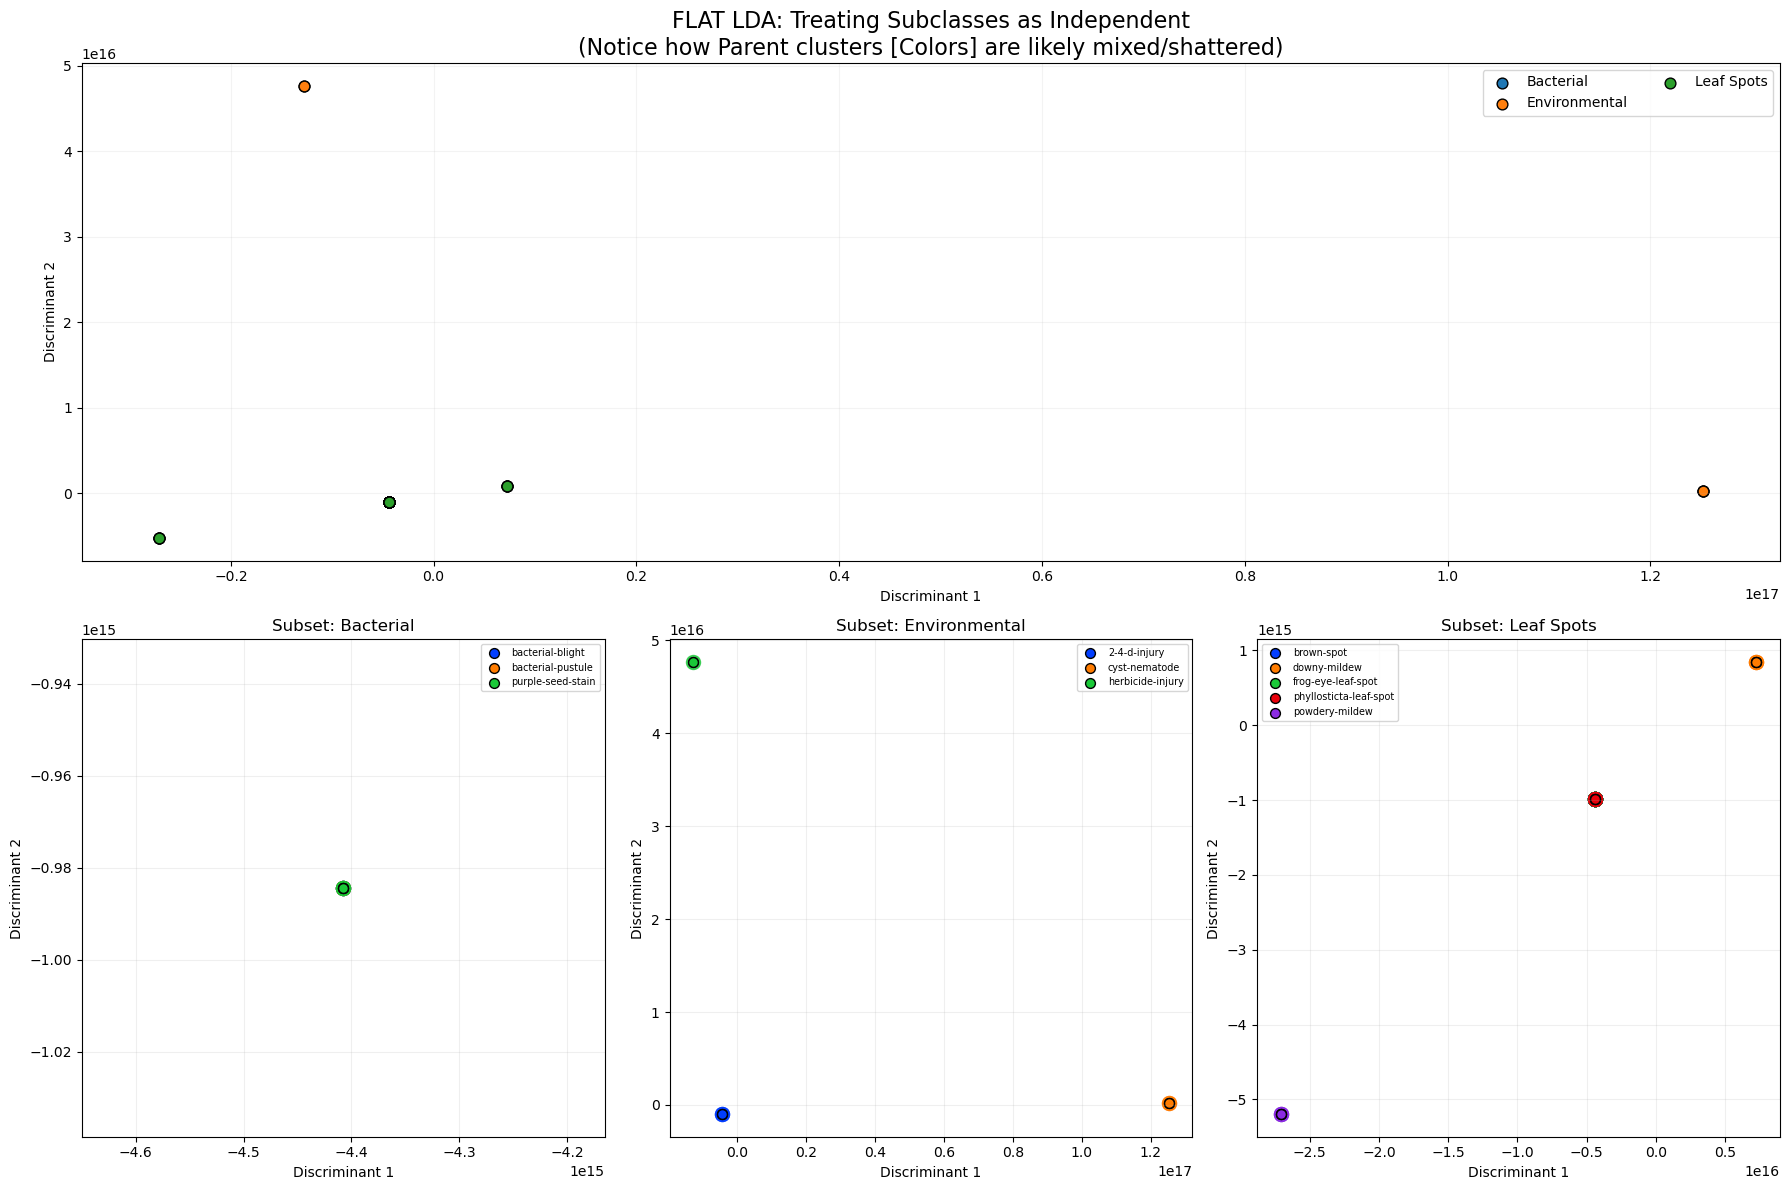

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ==========================================
# 1. Data Loading (Same as before)
# ==========================================
def get_soybean_data():
    print("Loading Soybean Data...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X, y = soybean.data, soybean.target
    
    X = SimpleImputer(strategy='most_frequent').fit_transform(X)
    X = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit_transform(X)
    
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial', 'purple-seed-stain': 'Bacterial',
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental', 'cyst-nematode': 'Environmental'
    }
    
    y_str = y.astype(str)
    y_parent = np.array([hierarchy_map.get(label, 'Other') for label in y_str])
    
    mask = (y_parent != 'Other') & (y_parent != 'Root/Stem Rots')
    print(f"Dropping 'Root/Stem Rots' and 'Other'... Keeping {np.sum(mask)} samples.")
    
    X, y_str, y_parent = X[mask], y_str[mask], y_parent[mask]
    
    le_p = LabelEncoder(); y_p = le_p.fit_transform(y_parent)
    le_s = LabelEncoder(); y_s = le_s.fit_transform(y_str)
    
    return StandardScaler().fit_transform(X), y_p, y_s, le_p, le_s

# ==========================================
# 2. Main Execution (Flat LDA)
# ==========================================
if __name__ == "__main__":
    X, y_p, y_s, le_p, le_s = get_soybean_data()
    
    # Split
    X_train, X_test, yp_train, yp_test, ys_train, ys_test = train_test_split(
        X, y_p, y_s, test_size=0.20, stratify=y_s, random_state=42
    )

    print("\n--- Training Flat LDA (Treating Subclasses as Independent) ---")
    # We use ys_train (Subclasses) as the target, completely ignoring yp_train (Parents)
    lda = LinearDiscriminantAnalysis(n_components=2)
    lda.fit(X_train, ys_train) 
    
    # Project Data
    P_train = lda.transform(X_train)
    P_test = lda.transform(X_test)
    
    # ==========================================
    # 3. Visualization (Exact same layout)
    # ==========================================
    unique_parents = np.unique(yp_test)
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, len(unique_parents))
    
    # --- A. Global View (Top) ---
    # We color by PARENT here to show how the Parent info is LOST/SCATTERED
    ax_global = fig.add_subplot(gs[0, :])
    cmap = plt.colormaps['tab10']
    
    for i, p_idx in enumerate(unique_parents):
        p_name = le_p.inverse_transform([p_idx])[0]
        
        # Plot Train (Background)
        tr_mask = yp_train == p_idx
        ax_global.scatter(P_train[tr_mask, 0], P_train[tr_mask, 1], 
                          color=cmap(i), alpha=0.3, s=40)
        
        # Plot Test (Foreground)
        te_mask = yp_test == p_idx
        ax_global.scatter(P_test[te_mask, 0], P_test[te_mask, 1], 
                          color=cmap(i), alpha=1.0, s=60, edgecolor='k', label=f"{p_name}")

    ax_global.set_title("FLAT LDA: Treating Subclasses as Independent\n(Notice how Parent clusters [Colors] are likely mixed/shattered)", fontsize=16)
    ax_global.set_xlabel("Discriminant 1")
    ax_global.set_ylabel("Discriminant 2")
    ax_global.legend(loc='best', ncol=2)
    ax_global.grid(True, alpha=0.15)

    # --- B. Subclass Zoom Views (Bottom) ---
    print("Generating Zoomed Views...")
    
    for i, p_idx in enumerate(unique_parents):
        ax = fig.add_subplot(gs[1, i])
        p_name = le_p.inverse_transform([p_idx])[0]
        
        # Filter Data by Parent (just for visualization purposes)
        tr_mask = yp_train == p_idx
        te_mask = yp_test == p_idx
        
        # Subclass Palette
        unique_subs = np.unique(ys_train[tr_mask]) 
        sub_palette = sns.color_palette("bright", len(unique_subs))
        
        for j, s_idx in enumerate(unique_subs):
            s_name = le_s.inverse_transform([s_idx])[0]
            
            # Train Data 
            s_tr = (ys_train == s_idx)
            ax.scatter(P_train[s_tr, 0], P_train[s_tr, 1], 
                       color=sub_palette[j], alpha=0.2, s=100) 
            
            # Test Data 
            s_te = (ys_test == s_idx)
            ax.scatter(P_test[s_te, 0], P_test[s_te, 1], label=s_name,
                       color=sub_palette[j], alpha=1.0, s=50, edgecolor='k')
            
        ax.set_title(f"Subset: {p_name}", fontsize=12)
        ax.set_xlabel("Discriminant 1")
        ax.set_ylabel("Discriminant 2")
        ax.legend(fontsize='x-small', loc='best')
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

Loading Soybean Data...
Dropping 'Root/Stem Rots' and 'Other'... Keeping 341 samples.

--- Training Parent LDA (Ignoring Subclasses) ---
Generating Zoomed Views (Colored by Subclass)...


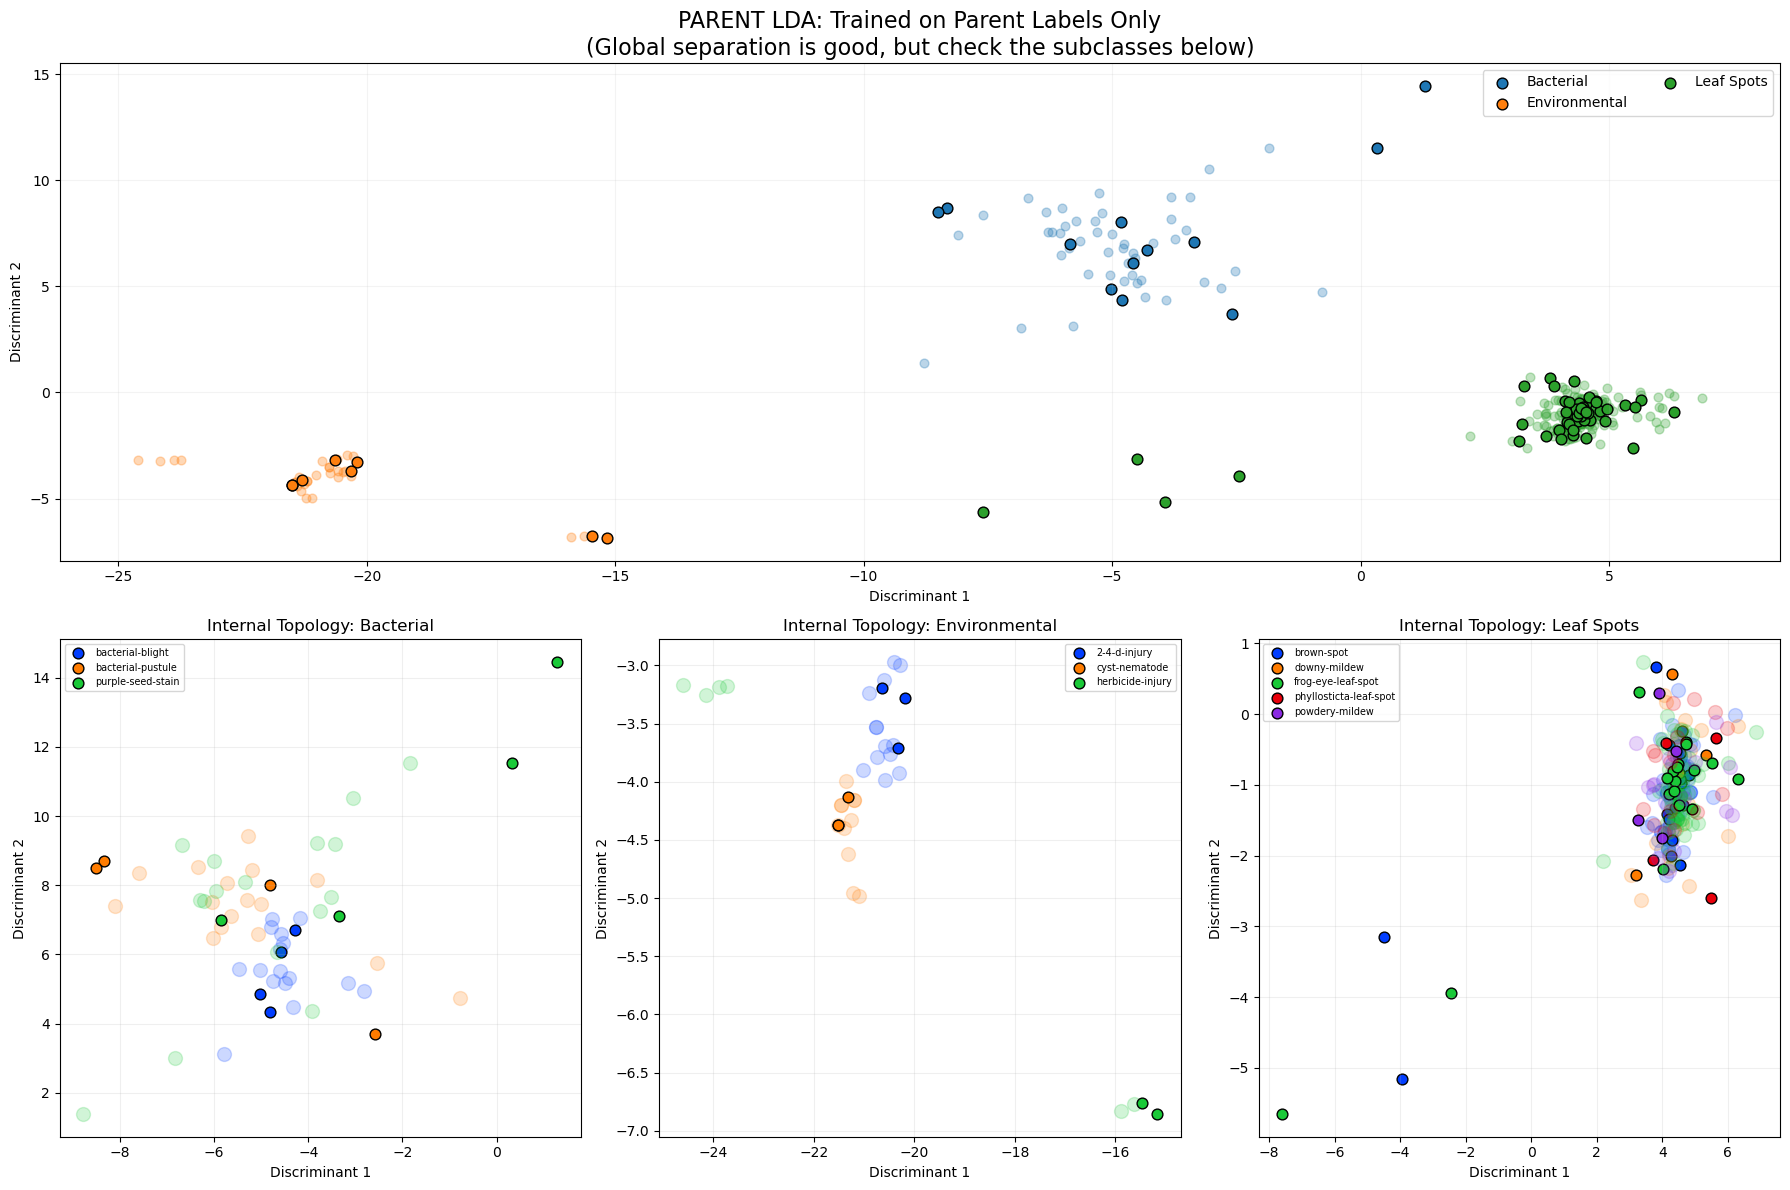

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ==========================================
# 1. Data Loading
# ==========================================
def get_soybean_data():
    print("Loading Soybean Data...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X, y = soybean.data, soybean.target
    
    X = SimpleImputer(strategy='most_frequent').fit_transform(X)
    X = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit_transform(X)
    
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial', 'purple-seed-stain': 'Bacterial',
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental', 'cyst-nematode': 'Environmental'
    }
    
    y_str = y.astype(str)
    y_parent = np.array([hierarchy_map.get(label, 'Other') for label in y_str])
    
    mask = (y_parent != 'Other') & (y_parent != 'Root/Stem Rots')
    print(f"Dropping 'Root/Stem Rots' and 'Other'... Keeping {np.sum(mask)} samples.")
    
    X, y_str, y_parent = X[mask], y_str[mask], y_parent[mask]
    
    le_p = LabelEncoder(); y_p = le_p.fit_transform(y_parent)
    le_s = LabelEncoder(); y_s = le_s.fit_transform(y_str)
    
    return StandardScaler().fit_transform(X), y_p, y_s, le_p, le_s

# ==========================================
# 2. Main Execution (Parent LDA)
# ==========================================
if __name__ == "__main__":
    X, y_p, y_s, le_p, le_s = get_soybean_data()
    
    # Split
    X_train, X_test, yp_train, yp_test, ys_train, ys_test = train_test_split(
        X, y_p, y_s, test_size=0.20, stratify=y_s, random_state=42
    )

    print("\n--- Training Parent LDA (Ignoring Subclasses) ---")
    # CHANGE: Trained on yp_train (Parents) instead of ys_train (Subclasses)
    lda = LinearDiscriminantAnalysis(n_components=2)
    lda.fit(X_train, yp_train) 
    
    # Project Data
    P_train = lda.transform(X_train)
    P_test = lda.transform(X_test)
    
    # ==========================================
    # 3. Visualization
    # ==========================================
    unique_parents = np.unique(yp_test)
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, len(unique_parents))
    
    # --- A. Global View (Top) ---
    # Colored by PARENT to show successful global separation
    ax_global = fig.add_subplot(gs[0, :])
    cmap = plt.colormaps['tab10']
    
    for i, p_idx in enumerate(unique_parents):
        p_name = le_p.inverse_transform([p_idx])[0]
        
        # Plot Train
        tr_mask = yp_train == p_idx
        ax_global.scatter(P_train[tr_mask, 0], P_train[tr_mask, 1], 
                          color=cmap(i), alpha=0.3, s=40)
        
        # Plot Test
        te_mask = yp_test == p_idx
        ax_global.scatter(P_test[te_mask, 0], P_test[te_mask, 1], 
                          color=cmap(i), alpha=1.0, s=60, edgecolor='k', label=f"{p_name}")

    ax_global.set_title("PARENT LDA: Trained on Parent Labels Only\n(Global separation is good, but check the subclasses below)", fontsize=16)
    ax_global.set_xlabel("Discriminant 1")
    ax_global.set_ylabel("Discriminant 2")
    ax_global.legend(loc='best', ncol=2)
    ax_global.grid(True, alpha=0.15)

    # --- B. Subclass Zoom Views (Bottom) ---
    # Colored by SUBCLASS to reveal potential collapse
    print("Generating Zoomed Views (Colored by Subclass)...")
    
    for i, p_idx in enumerate(unique_parents):
        ax = fig.add_subplot(gs[1, i])
        p_name = le_p.inverse_transform([p_idx])[0]
        
        # Filter Data by Parent
        tr_mask = yp_train == p_idx
        te_mask = yp_test == p_idx
        
        # Subclass Palette (Distinct colors for subclasses within this parent)
        unique_subs = np.unique(ys_train[tr_mask]) 
        sub_palette = sns.color_palette("bright", len(unique_subs))
        
        for j, s_idx in enumerate(unique_subs):
            s_name = le_s.inverse_transform([s_idx])[0]
            
            # Train Data
            s_tr = (ys_train == s_idx)
            ax.scatter(P_train[s_tr, 0], P_train[s_tr, 1], 
                       color=sub_palette[j], alpha=0.2, s=100) 
            
            # Test Data
            s_te = (ys_test == s_idx)
            ax.scatter(P_test[s_te, 0], P_test[s_te, 1], label=s_name,
                       color=sub_palette[j], alpha=1.0, s=60, edgecolor='k')
            
        ax.set_title(f"Internal Topology: {p_name}", fontsize=12)
        ax.set_xlabel("Discriminant 1")
        ax.set_ylabel("Discriminant 2")
        ax.legend(fontsize='x-small', loc='best')
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # Standard LDA
import itertools

# ==========================================
# 1. Data Loading
# ==========================================
def get_soybean_data():
    print("Loading Soybean Data...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X, y = soybean.data, soybean.target
    
    X = SimpleImputer(strategy='most_frequent').fit_transform(X)
    X = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit_transform(X)
    
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial', 'purple-seed-stain': 'Bacterial',
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental', 'cyst-nematode': 'Environmental'
    }
    
    y_str = y.astype(str)
    y_parent = np.array([hierarchy_map.get(label, 'Other') for label in y_str])
    
    # Filter
    mask = (y_parent != 'Other') #& (y_parent != 'Root/Stem Rots')
    print(f"Dropping 'Other'... Keeping {np.sum(mask)} samples.")
    
    X, y_str, y_parent = X[mask], y_str[mask], y_parent[mask]
    
    le_p = LabelEncoder(); y_p = le_p.fit_transform(y_parent)
    le_s = LabelEncoder(); y_s = le_s.fit_transform(y_str)
    
    return StandardScaler().fit_transform(X), y_p, y_s, le_p, le_s

# ==========================================
# 2. Matrices (For hLDA)
# ==========================================
def compute_matrices(X, y_p, y_s):
    dims = X.shape[1]
    S_B = np.zeros((dims, dims)); S_WS = np.zeros((dims, dims)); S_BS = np.zeros((dims, dims))
    overall_mean = np.mean(X, axis=0)
    
    subclass_means = {}
    
    for c in np.unique(y_p):
        idx_c = np.where(y_p == c)[0]
        mu_c = np.mean(X[idx_c], axis=0)
        S_B += len(idx_c) * np.outer(mu_c - overall_mean, mu_c - overall_mean)
        
        subclass_means[c] = []
        c_subs = np.unique(y_s[idx_c])
        
        for s in c_subs:
            idx_s = np.where((y_p == c) & (y_s == s))[0]
            X_s = X[idx_s]
            mu_s = np.mean(X_s, axis=0)
            subclass_means[c].append(mu_s)
            
            diff = X_s - mu_s
            S_WS += diff.T @ diff
            S_BS += len(X_s) * np.outer(mu_s - mu_c, mu_s - mu_c)
            
    return S_B, S_WS, S_BS, subclass_means

# ==========================================
# 3. Algorithm: hLDA (Balanced)
# ==========================================
def optimize_balanced(S_B, S_WS, S_BS, subclass_means, dims, n_comp=3):
    W = np.random.randn(dims, n_comp); W, _ = np.linalg.qr(W)
    gamma = 0.2; l1 = 5.0
    
    Denominator = S_WS + gamma * S_BS + 1e-4 * np.eye(dims)
    Numerator = S_B
    
    for i in range(300):
        N = W.T @ Numerator @ W
        D = W.T @ Denominator @ W
        D_inv = np.linalg.inv(D)
        grad_LDA = 2 * (Numerator @ W @ D_inv - Denominator @ W @ D_inv @ N @ D_inv)
        
        grad_Repulsion = np.zeros_like(W)
        for c, means in subclass_means.items():
            for m1, m2 in itertools.combinations(means, 2):
                diff = m1 - m2; proj = W.T @ diff
                dist_sq = np.dot(proj, proj) + 1e-6
                grad_Repulsion += (1.0 / dist_sq**2) * np.outer(diff, proj)
        
        W += 1e-4 * (grad_LDA + l1 * grad_Repulsion)
        W, _ = np.linalg.qr(W)
        
    return W

# ==========================================
# 4. Evaluation Helper
# ==========================================
def evaluate_projection(X_train, y_train_p, y_train_s, X_val, y_val_p, y_val_s, Transformer, is_sklearn=False):
    # Transform Data
    if is_sklearn:
        P_train = Transformer.transform(X_train)
        P_val = Transformer.transform(X_val)
    else:
        P_train = X_train @ Transformer
        P_val = X_val @ Transformer
    
    # 1. Parent Acc (1-NN)
    knn_p = KNeighborsClassifier(n_neighbors=1).fit(P_train, y_train_p)
    acc_p = accuracy_score(y_val_p, knn_p.predict(P_val))
    
    # 2. Subclass Acc (1-NN)
    knn_s = KNeighborsClassifier(n_neighbors=1).fit(P_train, y_train_s)
    acc_s = accuracy_score(y_val_s, knn_s.predict(P_val))
    
    return acc_p, acc_s

# ==========================================
# 5. Main Execution
# ==========================================
if __name__ == "__main__":
    X, y_p, y_s, le_p, le_s = get_soybean_data()
    
    X_train, X_test, yp_train, yp_test, ys_train, ys_test = train_test_split(
        X, y_p, y_s, test_size=0.20, stratify=y_s, random_state=42
    )
    
    # CV
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Store Results
    std_res = {'p': [], 's': []} # Standard LDA results
    hlda_res = {'p': [], 's': []} # hLDA results
    
    print("\n--- Starting Comparative 5-Fold CV ---")
    print(f"{'Fold':<6} | {'Std Parent':<12} {'Std Sub':<10} | {'hLDA Parent':<12} {'hLDA Sub':<10}")
    print("-" * 60)
    
    for fold, (t_idx, v_idx) in enumerate(kfold.split(X_train, ys_train)):
        # Data Slices
        xt, xv = X_train[t_idx], X_train[v_idx]
        ypt, ypv = yp_train[t_idx], yp_train[v_idx]
        yst, ysv = ys_train[t_idx], ys_train[v_idx]
        
        # --- A. Standard 3-Class LDA ---
        # Note: 3 classes -> max 2 discriminants
        lda_standard = LinearDiscriminantAnalysis(n_components=2)
        lda_standard.fit(xt, ypt) # Fit on PARENTS only
        
        std_p, std_s = evaluate_projection(xt, ypt, yst, xv, ypv, ysv, lda_standard, is_sklearn=True)
        std_res['p'].append(std_p); std_res['s'].append(std_s)
        
        # --- B. hLDA (Balanced) ---
        S_B, S_WS, S_BS, sub_means = compute_matrices(xt, ypt, yst)
        W_hlda = optimize_balanced(S_B, S_WS, S_BS, sub_means, X.shape[1], n_comp=3)
        
        h_p, h_s = evaluate_projection(xt, ypt, yst, xv, ypv, ysv, W_hlda, is_sklearn=False)
        hlda_res['p'].append(h_p); hlda_res['s'].append(h_s)
        
        print(f"{fold+1:<6} | {std_p:.3f}        {std_s:.3f}      | {h_p:.3f}        {h_s:.3f}")

    # Summary
    print("-" * 60)
    print(f"AVG    | {np.mean(std_res['p']):.3f}        {np.mean(std_res['s']):.3f}      | {np.mean(hlda_res['p']):.3f}        {np.mean(hlda_res['s']):.3f}")
    
    print("\n--- Interpretation ---")
    print("If hLDA Sub > Std Sub, your method successfully preserves internal structure.")
    print("If hLDA Parent < Std Parent, that is the expected trade-off (Global vs Local).")

Loading Soybean Data...
Dropping 'Other'... Keeping 592 samples.

--- Starting Comparative 5-Fold CV ---
Fold   | Std Parent   Std Sub    | hLDA Parent  hLDA Sub  
------------------------------------------------------------
1      | 0.968        0.547      | 0.905        0.821
2      | 0.979        0.611      | 0.905        0.821
3      | 1.000        0.558      | 0.863        0.821
4      | 0.979        0.585      | 0.851        0.766
5      | 0.968        0.532      | 0.723        0.660
------------------------------------------------------------
AVG    | 0.979        0.567      | 0.850        0.778

--- Interpretation ---
If hLDA Sub > Std Sub, your method successfully preserves internal structure.
If hLDA Parent < Std Parent, that is the expected trade-off (Global vs Local).



--- Dimension: 50 ---
1. Generating Data...
2. Computing Scatter Matrices...
Running Grid Search V5 (Tug-of-War)...
Total Combinations: 12
Processed 10/12 | Best Obj: 14505.69     
Grid Search Complete. Best Obj: 14505.6909
Visualizing Best Grid Search Result...


/var/folders/mr/3pmylcxd56l5330m7rrk4jlw0000gp/T/ipykernel_4216/2088587971.py:199: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_parents = cm.get_cmap('viridis', len(u_parents))


3. Running Full Gradient Ascent using Best Grid Params...
Iter 9950: Obj=114.3560 | Anchor(g)=1.00, Repel(l1)=1.0000
Final Result: Obj=11.4684

--- Dimension: 100 ---
1. Generating Data...
2. Computing Scatter Matrices...
Running Grid Search V5 (Tug-of-War)...
Total Combinations: 12
Processed 10/12 | Best Obj: 2028.39     
Grid Search Complete. Best Obj: 2028.3920
Visualizing Best Grid Search Result...
3. Running Full Gradient Ascent using Best Grid Params...
Iter 9950: Obj=7311.2876 | Anchor(g)=0.10, Repel(l1)=50.000
Final Result: Obj=12369.1156

--- Dimension: 500 ---
1. Generating Data...
2. Computing Scatter Matrices...
Running Grid Search V5 (Tug-of-War)...
Total Combinations: 12
Processed 10/12 | Best Obj: 259.18     
Grid Search Complete. Best Obj: 259.1754
Visualizing Best Grid Search Result...
3. Running Full Gradient Ascent using Best Grid Params...
Iter 9950: Obj=23.0617 | Anchor(g)=0.10, Repel(l1)=1.00000
Final Result: Obj=187.8616

--- Dimension: 1000 ---
1. Generating Dat

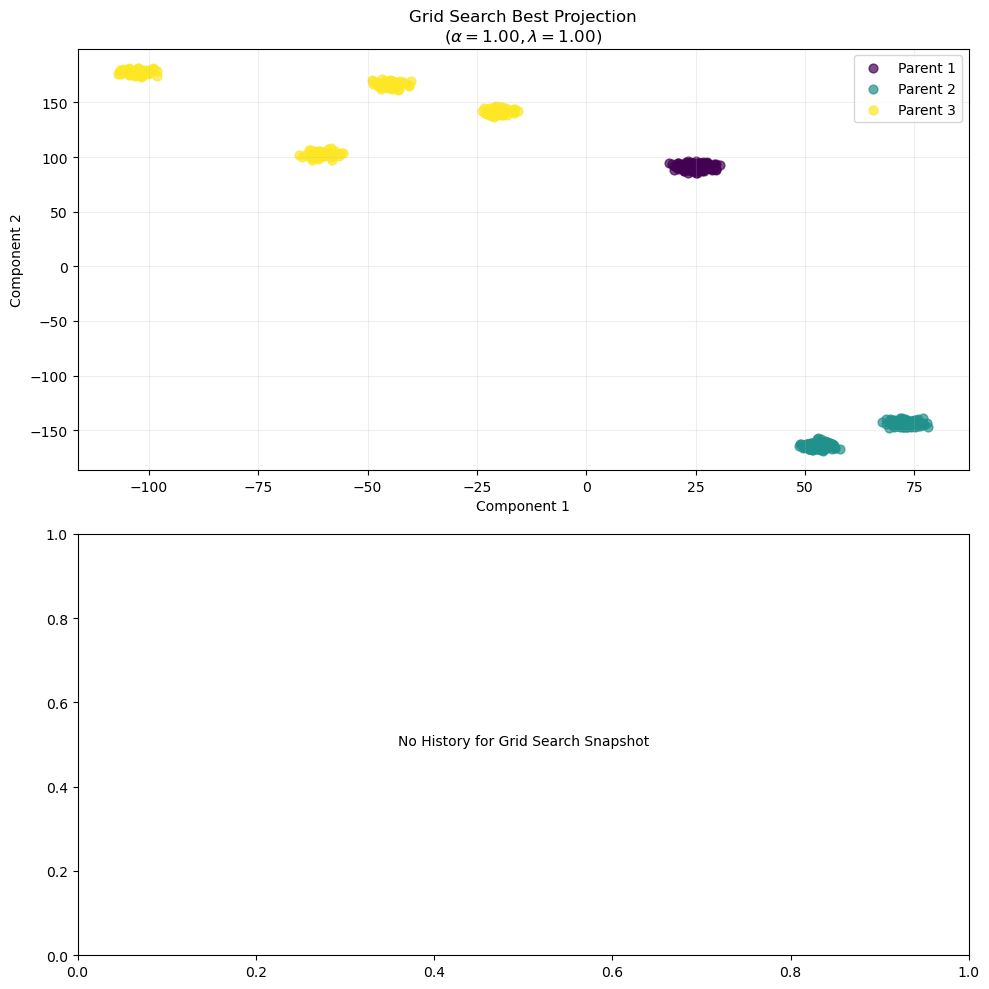

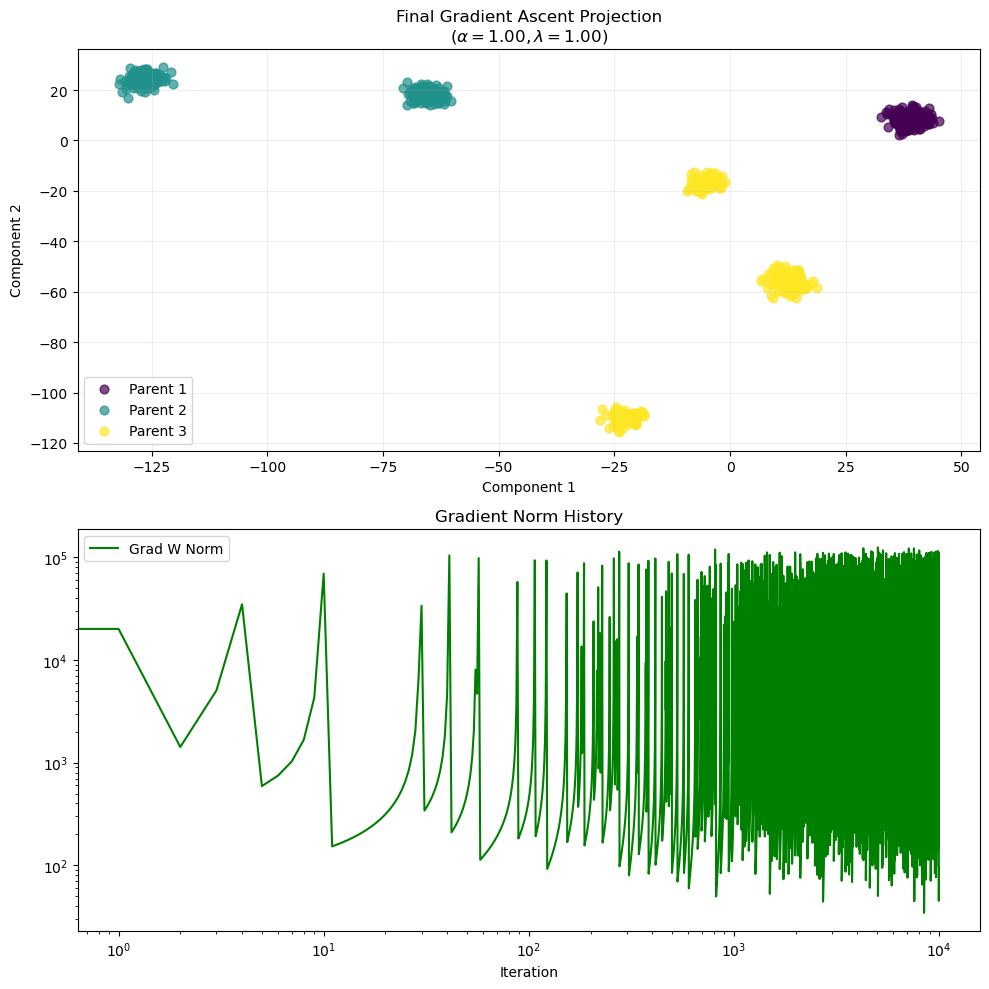

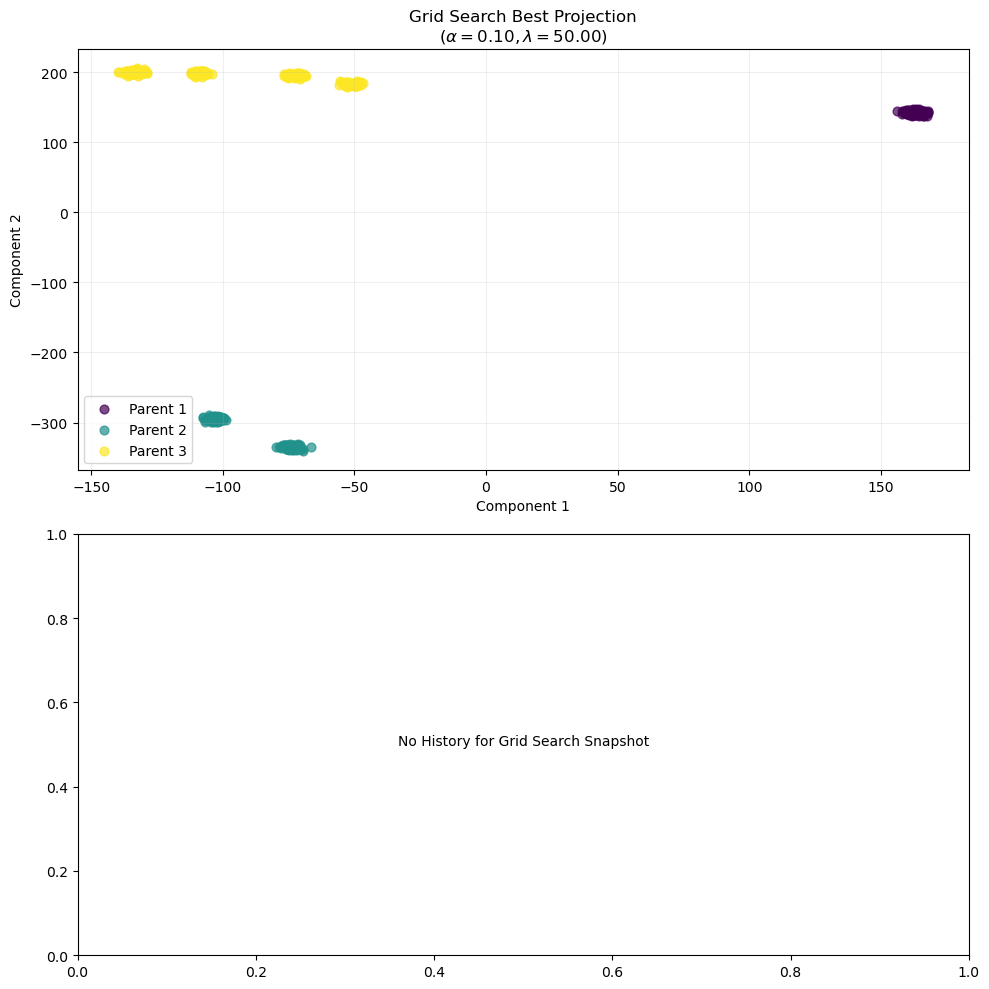

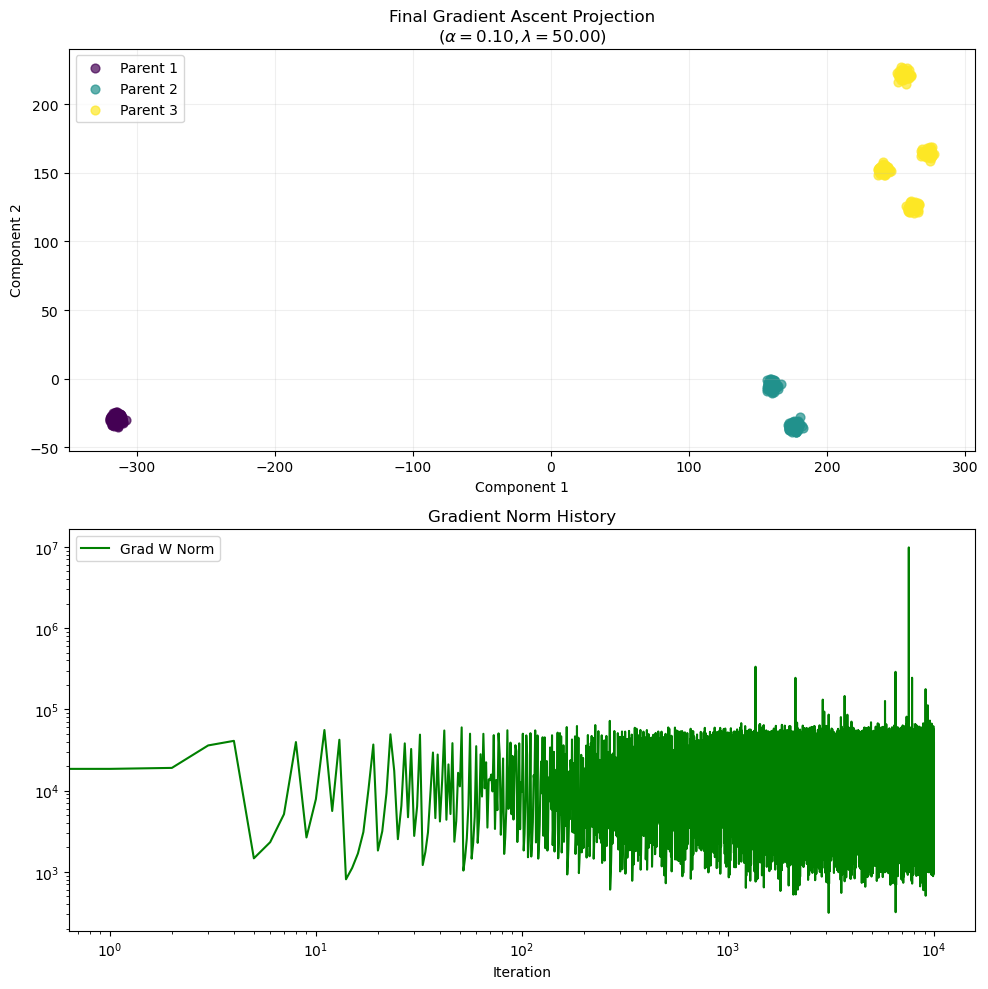

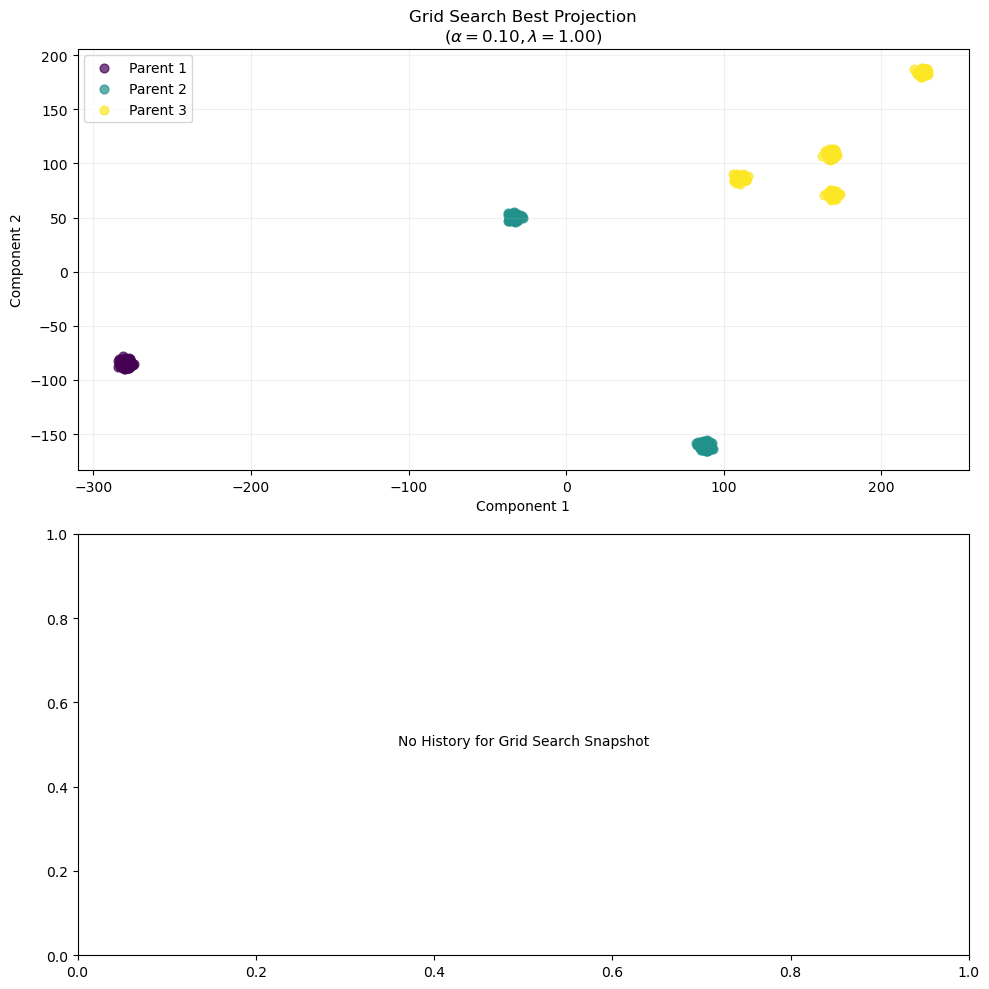

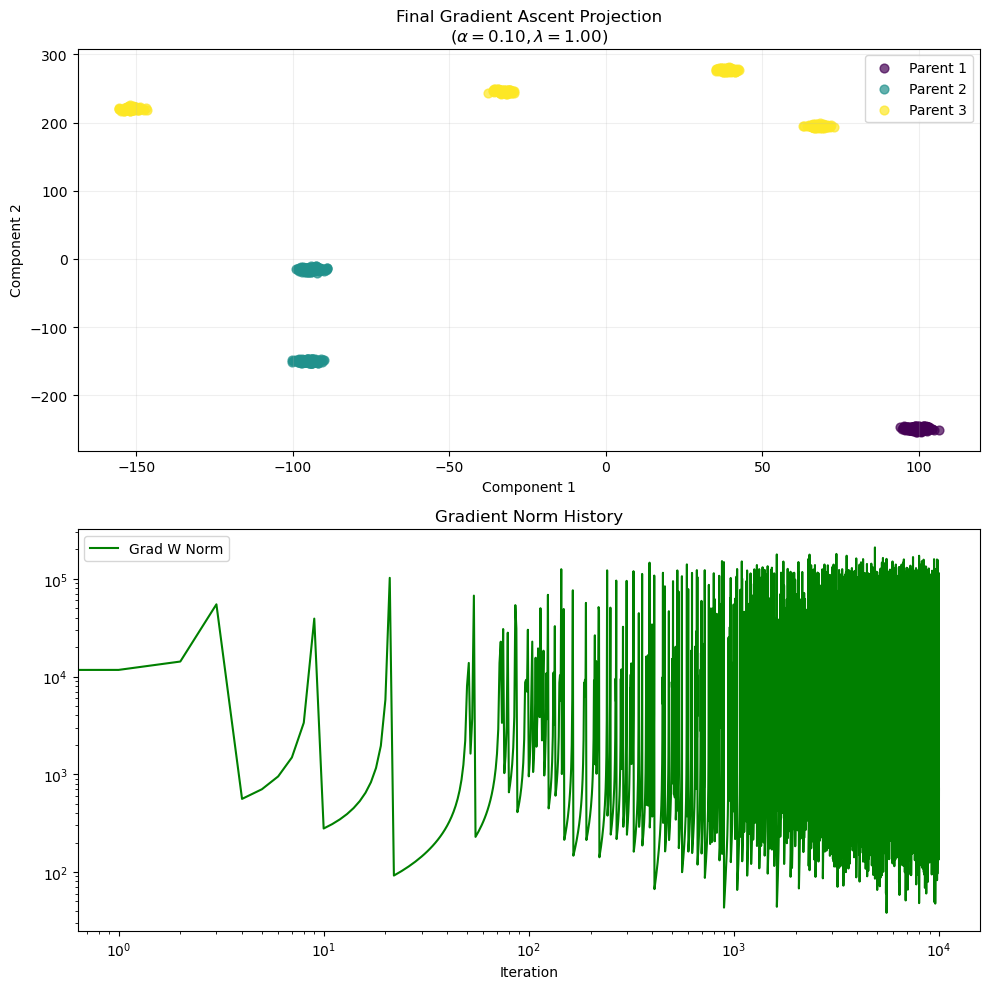

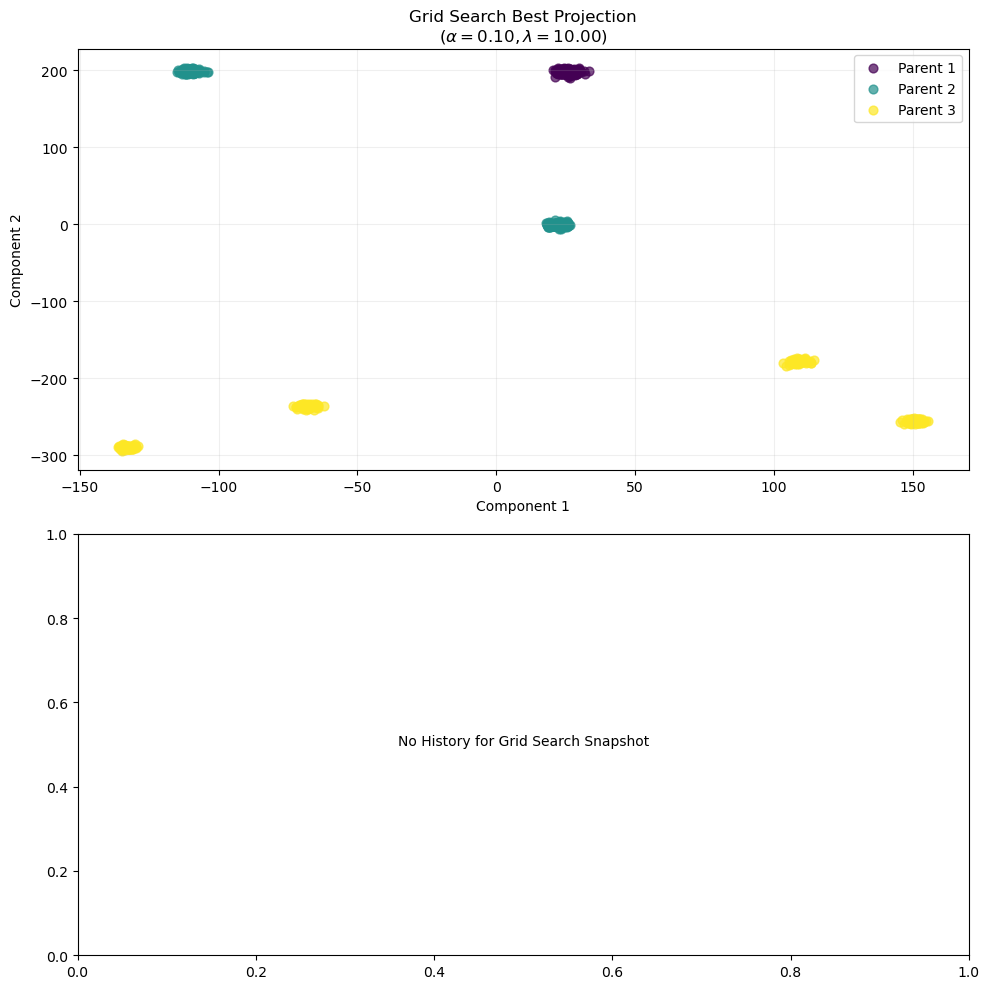

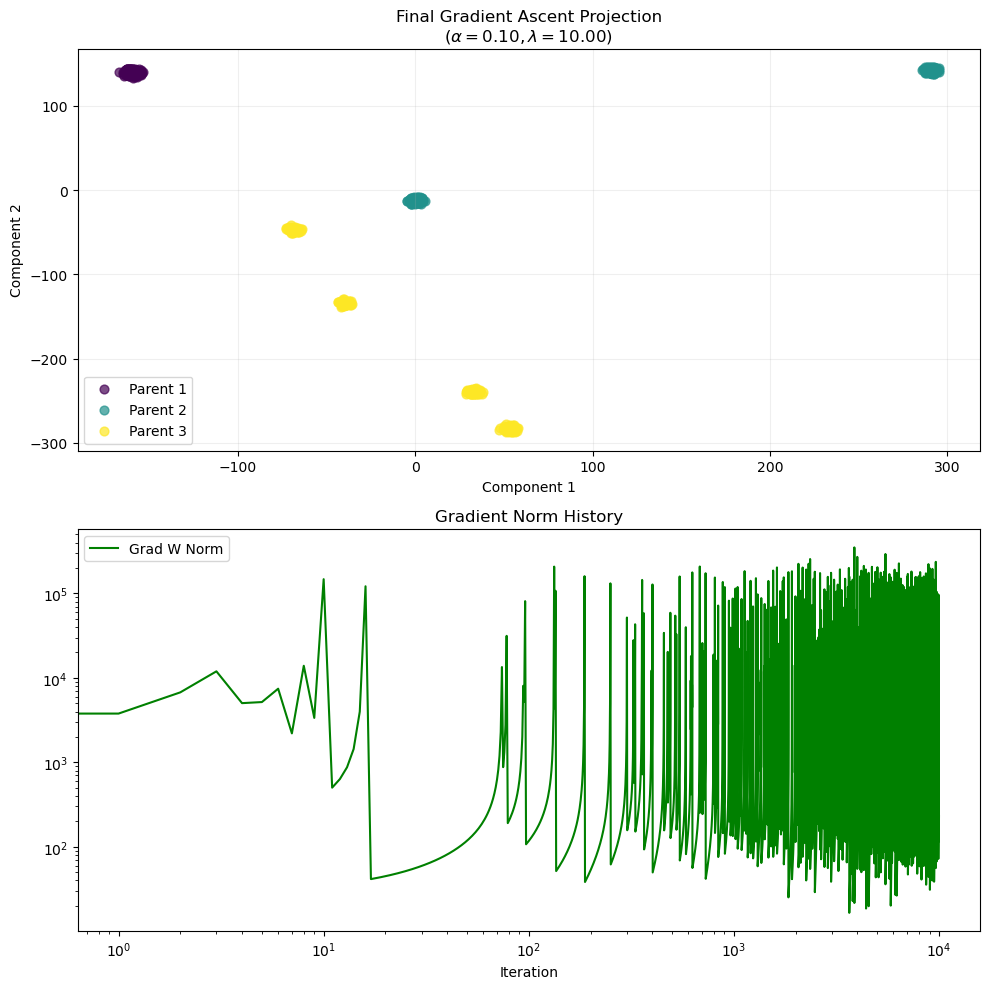

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import itertools
import time
import os

# ==========================================
# 1. Data Generation (Same as v4)
# ==========================================
def generate_data(dims=1000):
    # np.random.seed(42)
    clusters_per_class = {1: [300], 2: [150, 150], 3: [75, 75, 75, 75]}
    
    # Standard deviations
    subclass_std = 8
    cluster_std = 2
    mean_scale = 400 
    class_means = {}
    
    for c_label in clusters_per_class.keys():
        rand_vec = np.random.randn(dims)
        unit_vec = rand_vec / (np.linalg.norm(rand_vec) + 1e-9)
        magnitude = mean_scale + np.random.uniform(0, 50)
        class_means[c_label] = unit_vec * magnitude

    data_points = []    
    labels_class = []    
    labels_cluster = []
    
    for class_label, cluster_sizes in clusters_per_class.items():
        base_mean = class_means[class_label]
        for cluster_index, n_points in enumerate(cluster_sizes, start=1):
            subclass_mean = base_mean + np.random.randn(dims) * subclass_std
            points = subclass_mean + np.random.randn(n_points, dims) * cluster_std
            
            data_points.append(points)
            labels_class.extend([class_label] * n_points)
            labels_cluster.extend([(class_label, cluster_index)] * n_points)
            
    return np.vstack(data_points), np.array(labels_class), np.array(labels_cluster)

# ==========================================
# 2. Matrices & Helper Functions
# ==========================================
def compute_matrices(data, labels_class, labels_cluster, dims):
    overall_mean = np.mean(data, axis=0)
    unique_classes = np.unique(labels_class)
    S_B = np.zeros((dims, dims)); S_WS = np.zeros((dims, dims)); S_BS = np.zeros((dims, dims))
    parent_means = {}; subclass_means = {}
    mu_tot = overall_mean
    
    for c in unique_classes:
        idx = np.where(labels_class == c)[0]
        X_c = data[idx, :]; N_c = X_c.shape[0]; mu_c = np.mean(X_c, axis=0)
        parent_means[c] = mu_c
        S_B += N_c * np.outer(mu_c - overall_mean, mu_c - overall_mean)
        
        class_subs = np.array([lbl[1] for lbl in labels_cluster[idx]])
        subclass_means[c] = []
        for sub in np.unique(class_subs):
            mask = np.array([(lbl[0] == c and lbl[1] == sub) for lbl in labels_cluster])
            idx_sub = np.where(mask)[0]; X_cs = data[idx_sub, :]
            N_cs = X_cs.shape[0]; mu_cs = np.mean(X_cs, axis=0)
            subclass_means[c].append(mu_cs)
            
            diff = X_cs - mu_cs
            S_WS += diff.T @ diff
            S_BS += N_cs * np.outer(mu_cs - mu_c, mu_cs - mu_c)
            
    return S_B, S_WS, S_BS, parent_means, subclass_means, mu_tot

# ==========================================
# 3. Optimization Logic (Tug-of-War / Balanced)
# ==========================================
def joint_gradient_ascent_v5(S_B, S_WS, S_BS, subclass_means, parent_means, mu_tot, 
                             reg=1e-4, num_iters=300, fix_hyperparams=None, verbose=True):
    dims = S_B.shape[0]
    W = np.random.randn(dims, 2); W, _ = np.linalg.qr(W)
    
    # Defaults
    # Gamma (Anchor): High = Tight orbit, Low = Loose orbit
    gamma = fix_hyperparams['gamma'] if fix_hyperparams else 0.5
    # L1 (Repulsion): High = Strong separation
    l1 = fix_hyperparams['l1'] if fix_hyperparams else 1.0
    
    step_W = 1e-4; eps = 1e-6
    history = []; hW = []
    
    # Pre-compute Numerator (Static)
    Numerator = S_B
    
    # Pre-compute Denominator Matrix (Anchor Logic)
    # S_BS is added to Denom to "shrink" subclasses to parents
    Denominator = S_WS + gamma * S_BS + reg * np.eye(dims)
    
    for it in range(num_iters):
        # 1. Base LDA Gradient (Ratio Trace)
        # J = Tr( (W' D W)^-1 (W' N W) )
        N_proj = W.T @ Numerator @ W
        D_proj = W.T @ Denominator @ W + eps * np.eye(2)
        D_inv = np.linalg.inv(D_proj)
        
        lda_val = np.trace(D_inv @ N_proj)
        
        # Gradient: 2 * (N W D_inv - D W K)
        term1 = 2 * Numerator @ W @ D_inv
        K = D_inv @ N_proj @ D_inv 
        term2 = 2 * Denominator @ W @ K
        grad_LDA = term1 - term2
        
        # 2. Anti-Collapse Gradient (Repulsion)
        # Force = 1 / dist^2 (Inverse Square Law)
        grad_Repulsion = np.zeros_like(W)
        if l1 > 0:
            for c, means in subclass_means.items():
                for i in range(len(means)):
                    for j in range(i+1, len(means)):
                        diff = means[i] - means[j]
                        proj = W.T @ diff
                        dist_sq = np.dot(proj, proj) + 1e-4
                        
                        # Gradient of -1/x^2 (Push Apart)
                        grad_Repulsion += (1.0 / dist_sq**2) * 2 * np.outer(diff, proj)

        # 3. Update
        W += step_W * (grad_LDA + l1 * grad_Repulsion)
        W, _ = np.linalg.qr(W)
        
        # Record
        history.append(lda_val)
        gnorm = np.linalg.norm(grad_LDA + l1 * grad_Repulsion)
        hW.append(gnorm)
        
        if verbose and it % 50 == 0:
            print(f"Iter {it}: Obj={lda_val:.4f} | Anchor(g)={gamma:.2f}, Repel(l1)={l1:.2f}", end='\r')
            
    return W, gamma, l1, history, hW

# ==========================================
# 4. Grid Search Wrapper
# ==========================================
def run_grid_search(S_B, S_WS, S_BS, sub_means, par_means, mu_tot, reg):
    print("Running Grid Search V5 (Tug-of-War)...")
    
    # V5 Parameters:
    # Gamma: Anchor Strength (0.1 = loose, 5.0 = tight)
    gammas = [0.1, 0.5, 1.0, 5.0]
    # L1: Repulsion Strength (1.0 = weak, 50.0 = strong)
    l1s = [1.0, 10.0, 50.0]
    
    grid = {'gamma': gammas, 'l1': l1s}
    keys, values = zip(*grid.items())
    
    best_obj = -np.inf
    best_params = None
    best_W = None
    
    total_combos = np.prod([len(v) for v in values])
    print(f"Total Combinations: {total_combos}")
    
    count = 0
    for bundle in itertools.product(*values):
        params = dict(zip(keys, bundle))
        
        # Short run for grid search
        W_curr, _, _, hist, _ = joint_gradient_ascent_v5(
            S_B, S_WS, S_BS, sub_means, par_means, mu_tot, 
            reg=reg, num_iters=30, fix_hyperparams=params, 
            verbose=False 
        )
        
        # Use final objective value
        val = hist[-1] if not np.isnan(hist[-1]) else -np.inf
        
        if val > best_obj:
            best_obj = val
            best_params = params
            best_W = W_curr.copy()
            
        count += 1
        if count % 5 == 0:
            print(f"Processed {count}/{total_combos} | Best Obj: {best_obj:.2f}     ", end='\r')
            
    print(f"\nGrid Search Complete. Best Obj: {best_obj:.4f}")
    return best_params, best_W, best_obj

# ==========================================
# 5. Visualizations
# ==========================================
def run_visualizations(W, gamma, l1, data, y_cls, y_clst, hist, hist_W, dims, best_obj, title_prefix):
    # 1. Full Projection
    proj = data @ W
    u_parents = np.unique(y_cls)
    
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    
    # Overall Scatter
    cmap_parents = cm.get_cmap('viridis', len(u_parents))
    for i, c in enumerate(u_parents):
        idx = np.where(y_cls == c)[0]
        axs[0].scatter(proj[idx, 0], proj[idx, 1], label=f'Parent {c}', 
                       color=cmap_parents(i), alpha=0.7, s=40)
        
    axs[0].set_title(f"{title_prefix} Projection\n" + rf"$(\alpha={gamma:.2f}, \lambda={l1:.2f})$")
    axs[0].set_xlabel("Component 1")
    axs[0].set_ylabel("Component 2")
    axs[0].legend()
    axs[0].grid(True, alpha=0.2)
    
    # Gradient History
    if hist_W and len(hist_W) > 0:
        axs[1].plot(hist_W, label='Grad W Norm', color='green')
        axs[1].set_yscale('log')
        axs[1].set_xscale('log')
        axs[1].set_title("Gradient Norm History")
        axs[1].set_xlabel("Iteration")
        axs[1].legend()
    else:
        axs[1].text(0.5, 0.5, "No History for Grid Search Snapshot", ha='center')

    plt.tight_layout()
    save_path = f'figs/hlda_v5/{dims}'
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, f"{title_prefix}_projection_{best_obj:.4f}.png"))

# ==========================================
# Main Execution
# ==========================================
if __name__ == "__main__":
    # dim_list = [3,3,3,3,3,10,10,10,10,50,50,50,50,100,100,100,100,500,500,500,500,1000,1000,1000,1000]
    dim_list = [50, 100, 500, 1000]
    
    for dims in dim_list:
        reg = 1e-4
        
        print(f"\n--- Dimension: {dims} ---")
        print("1. Generating Data...")
        data, y_cls, y_clst = generate_data(dims)
        
        print("2. Computing Scatter Matrices...")
        Sb, Sws, Sbs, pm, sm, mt = compute_matrices(data, y_cls, y_clst, dims)
        
        # --- PHASE A: GRID SEARCH ---
        best_p, best_W_grid, best_obj = run_grid_search(Sb, Sws, Sbs, sm, pm, mt, reg)
        
        # Visualize Grid Result
        print("Visualizing Best Grid Search Result...")
        run_visualizations(best_W_grid, best_p['gamma'], best_p['l1'],
                        data, y_cls, y_clst, [], [], dims, best_obj, title_prefix="Grid Search Best")
        
        # --- PHASE B: GRADIENT ASCENT ---
        print("3. Running Full Gradient Ascent using Best Grid Params...")
        W, g, l1, h, hW = joint_gradient_ascent_v5(
                Sb, Sws, Sbs, sm, pm, mt, 
                reg=reg, num_iters=10000, fix_hyperparams=best_p,
                verbose=True
            )
        
        print(f"\nFinal Result: Obj={h[-1]:.4f}")
        run_visualizations(W, g, l1, data, y_cls, y_clst, h, hW, dims, best_obj, title_prefix="Final Gradient Ascent")